- Filename: ViT-SOM_training_USPS.ipynb
- Author: Tomas Hanzlik <hanzlto3@fit.cvut.cz>
- Created: 2026-04-22
- Description: Training and visualizations of the ViT-SOM model on the USPS dataset

# ViT-SOM training  on USPS dataset

Training of both ViT-SOM models with 24x24 and 40x40 grids to compare achieved performance with the authors implementation

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import ConcatDataset
import numpy as np
import matplotlib.pyplot as plt


from ViTSOM import AutoEncoder, ViTLoss, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_som_pie_grid, plot_umap_som_weights, get_node_hits, plot_som_mnist, plot_som_weights

Download and concatenate the dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])


train_set = datasets.USPS(root="../data", train=True, download=True, transform=transform)
test_set = datasets.USPS(root="../data", train=False, download=True, transform=transform)
dataset = ConcatDataset([train_set, test_set])

100%|███████████████████████████████████████████████████████████████████████████████| 6.58M/6.58M [00:08<00:00, 742kB/s]
100%|███████████████████████████████████████████████████████████████████████████████| 1.83M/1.83M [00:02<00:00, 853kB/s]


## ViT-SOM with 24x24 grid

In [18]:
config_paper = {
    'img_size': 16,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'som_rows': 24,
    'som_cols': 24,
    'epochs': 200,
    'lr': 0.0005,
}

Initialize the ViT-SOM

Details:
- Image size of 16
- Pixel size of 4
- 1 image channel
- Embedding dimension of 16
- Encoder depth of 4
- Decoder depth of 2
- 2 self-attention head
- MLP hidden dimension of size 64
- 24 SOM rows
- 24 SOM columns
- 200 training epochs
- Learning rate of 0.0005


In [19]:
autoencoder = AutoEncoder(img_size=config_paper['img_size'], 
                          patch_size=config_paper['patch_size'], 
                          num_of_channels=config_paper['num_of_channels'], 
                          embed_dim=config_paper['embed_dim'], 
                          enc_depth=config_paper['enc_depth'],                                      
                          dec_depth=config_paper['dec_depth'], 
                          num_heads=config_paper['num_heads'], 
                          mlp_dim=config_paper['mlp_dim'], 
                          som_rows=config_paper['som_rows'], 
                          som_cols=config_paper['som_cols'])    

In [20]:
# Initialize optimizer, dataloader, loss functions and scheduler
optimizer = optim.AdamW(autoencoder.parameters(), lr=config_paper['lr'])
loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
criterionViT = ViTLoss()
criterionSOM = SomLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=config_paper['epochs'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)
autoencoder.train()

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = 5
sigma_end = 0.001
beta = (sigma_end / sigma_start) ** (1 / config_paper['epochs'])

# get grid coordinates of each cell on the SOM grid
grid_coords = get_grid_coords(config_paper['som_rows'], config_paper['som_cols'], device)
current_sigma = sigma_start

history = {'total': [], 'mse': [], 'som': [], 'purity': [], 'QE': [], 'TE': []}

# checkpoints and snapshots for visualizations
checkpoints = [0,20,40,60,80,100,120,140,160,180,200]
snapshot_som_weights = {}

snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

# set to calculate unique labels
unique_labels = set()

warmup_epochs = 10
target_gamma = 0.01
print("Start training")
for epoch in range(config_paper['epochs']):
    running_loss = 0.0
    running_mse = 0.0
    running_som = 0.0
    
    # using linear warmup on the sigma value, this demonstrated better results than standard decaying
    if epoch >= warmup_epochs:
        sigma_t = decay_exponential(sigma_start, beta, epoch - warmup_epochs)
    else:
        sigma_t = sigma_start
    
    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        # calculate the total loss using the linear warmup
        l_nn = criterionViT(images, reconstructed)
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        if epoch < warmup_epochs:
            gamma = target_gamma * (epoch / warmup_epochs)
        else:
            gamma = target_gamma
        total_loss = l_nn + gamma * l_som
        
        # update the weights of the network
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_mse += l_nn.item()
        running_som += l_som.item()
    
    if epoch+1 in checkpoints:      
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)
        
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()
    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_total = running_loss / len(loader)
    avg_mse = running_mse / len(loader)
    avg_som = running_som / len(loader)
    
    history['total'].append(avg_total)
    history['mse'].append(avg_mse)
    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config_paper['epochs']} | Sigma: {sigma_t:.2f} | Loss: {avg_total:.8f} (MSE: {avg_mse:.8f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")


Start training
Epoch 1/200 | Sigma: 5.00 | Loss: 0.04025045 (MSE: 0.04025045 | SOM: 124.58061889) | QE: 0.7750 | TE: 0.7947 | Purity: 0.24973
Epoch 2/200 | Sigma: 5.00 | Loss: 0.11946761 (MSE: 0.00854634 | SOM: 110.92126386) | QE: 0.5873 | TE: 0.9924 | Purity: 0.23048
Epoch 3/200 | Sigma: 5.00 | Loss: 0.12050315 (MSE: 0.00352192 | SOM: 58.49060970) | QE: 0.3777 | TE: 1.0000 | Purity: 0.16799
Epoch 4/200 | Sigma: 5.00 | Loss: 0.14067990 (MSE: 0.00221619 | SOM: 46.15457177) | QE: 0.2188 | TE: 0.9998 | Purity: 0.16703
Epoch 5/200 | Sigma: 5.00 | Loss: 0.15503073 (MSE: 0.00178257 | SOM: 38.31204047) | QE: 0.1223 | TE: 0.9831 | Purity: 0.16703
Epoch 6/200 | Sigma: 5.00 | Loss: 0.13687296 (MSE: 0.00158647 | SOM: 27.05729839) | QE: 0.0723 | TE: 0.7797 | Purity: 0.16703
Epoch 7/200 | Sigma: 5.00 | Loss: 0.11692116 (MSE: 0.00147818 | SOM: 19.24049716) | QE: 0.0425 | TE: 0.9002 | Purity: 0.16703
Epoch 8/200 | Sigma: 5.00 | Loss: 0.09602593 (MSE: 0.00138318 | SOM: 13.52039286) | QE: 0.0248 | TE: 

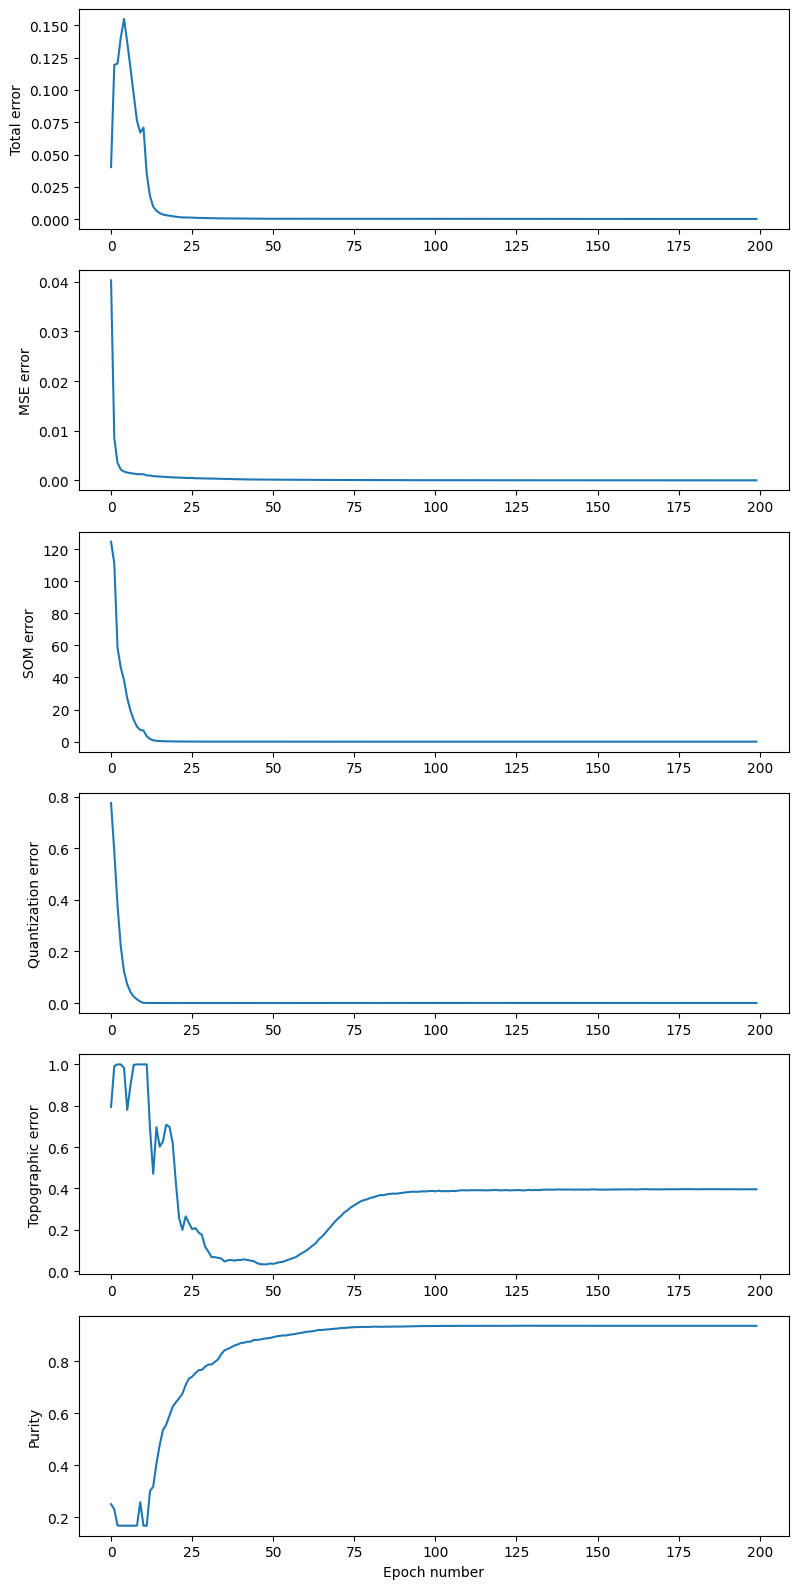

In [21]:
plt.figure(figsize=(8, 16))
plt.subplot(6,1,1)
plt.plot(np.arange(config_paper['epochs']), history['total'])
plt.ylabel('Total error')
plt.subplot(6,1,2)
plt.plot(np.arange(config_paper['epochs']), history['mse'])
plt.ylabel('MSE error')
plt.subplot(6,1,3)
plt.plot(np.arange(config_paper['epochs']), history['som'])
plt.ylabel('SOM error')
plt.subplot(6,1,4)
plt.plot(np.arange(config_paper['epochs']), history['QE'])
plt.ylabel('Quantization error')
plt.subplot(6,1,5)
plt.plot(np.arange(config_paper['epochs']), history['TE'])
plt.ylabel('Topographic error')
plt.subplot(6,1,6)
plt.plot(np.arange(config_paper['epochs']), history['purity'])
plt.ylabel('Purity')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

Plot the change of the label matrix throughout the training process

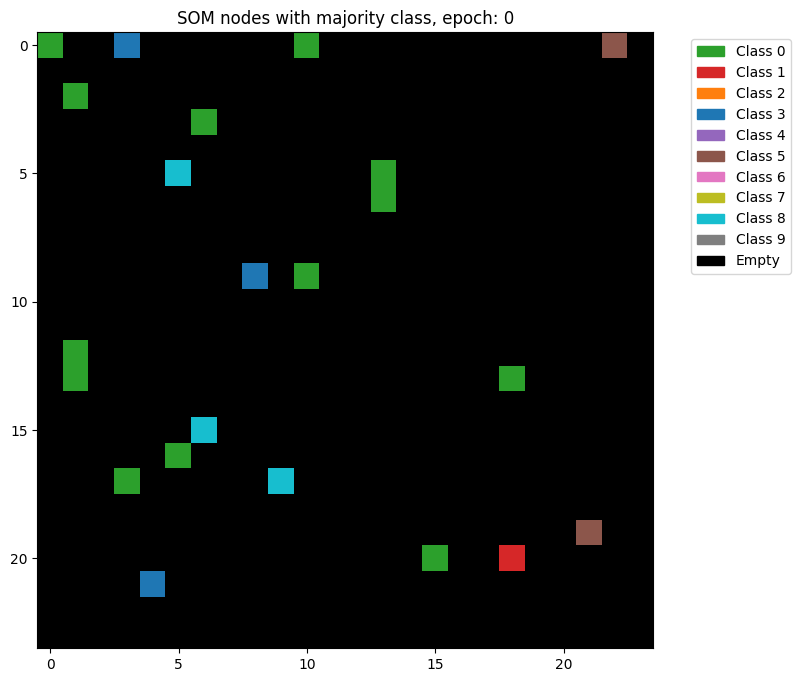

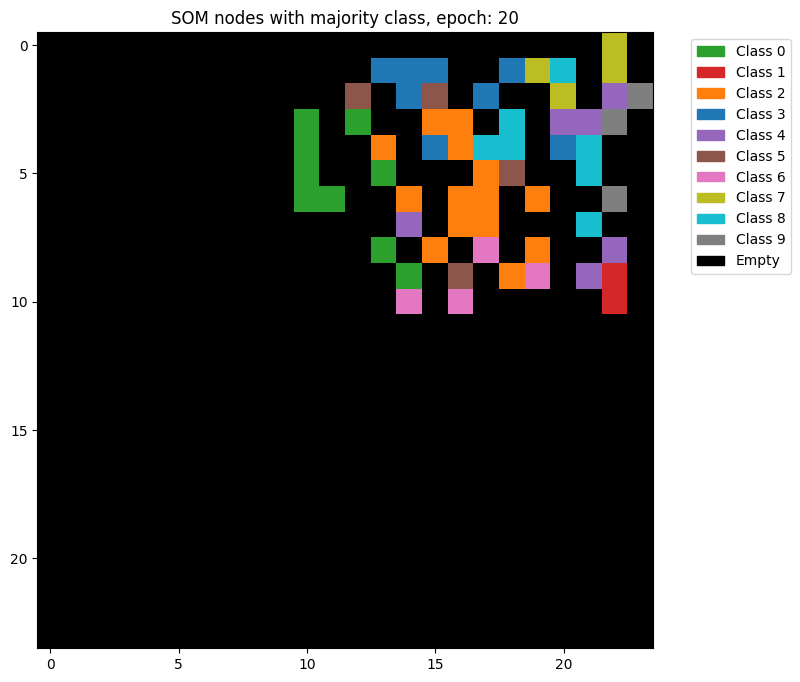

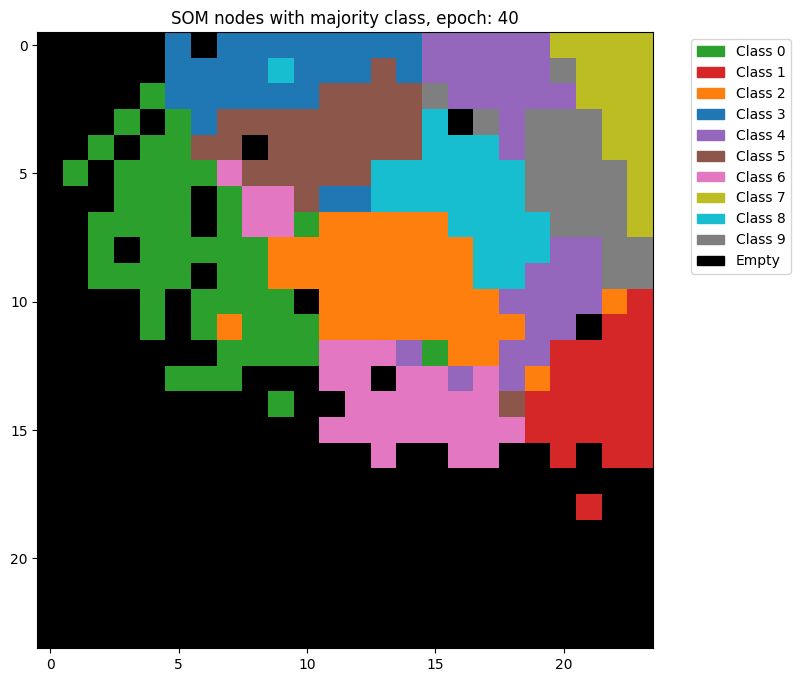

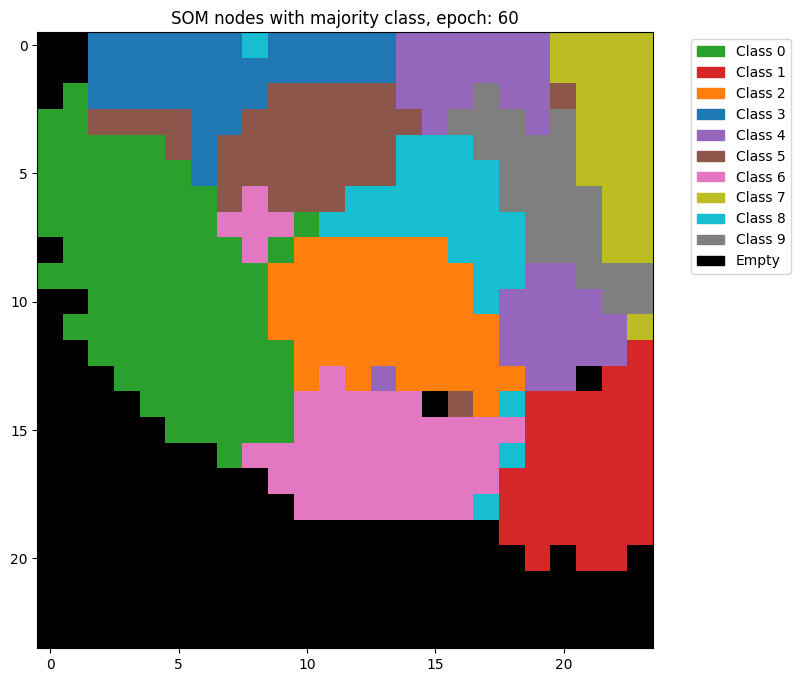

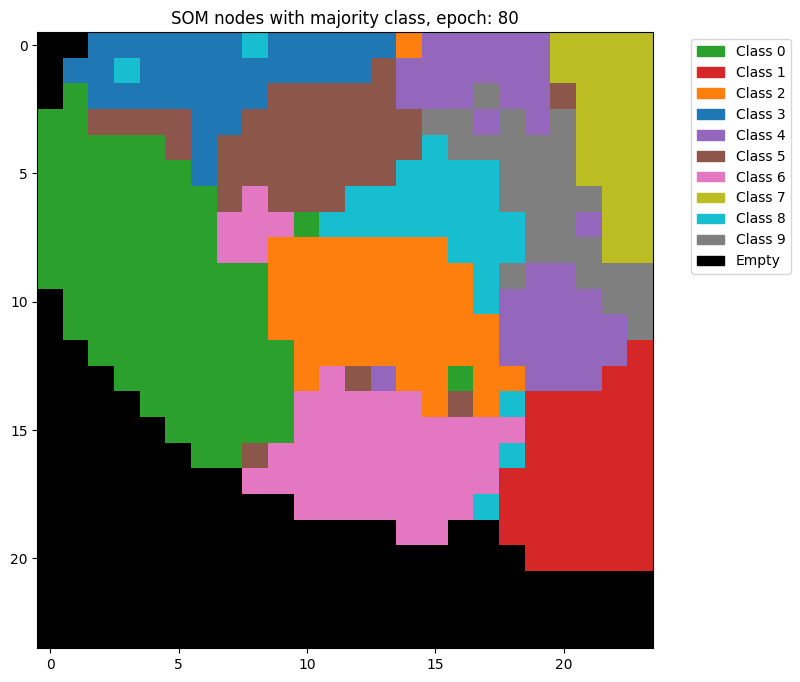

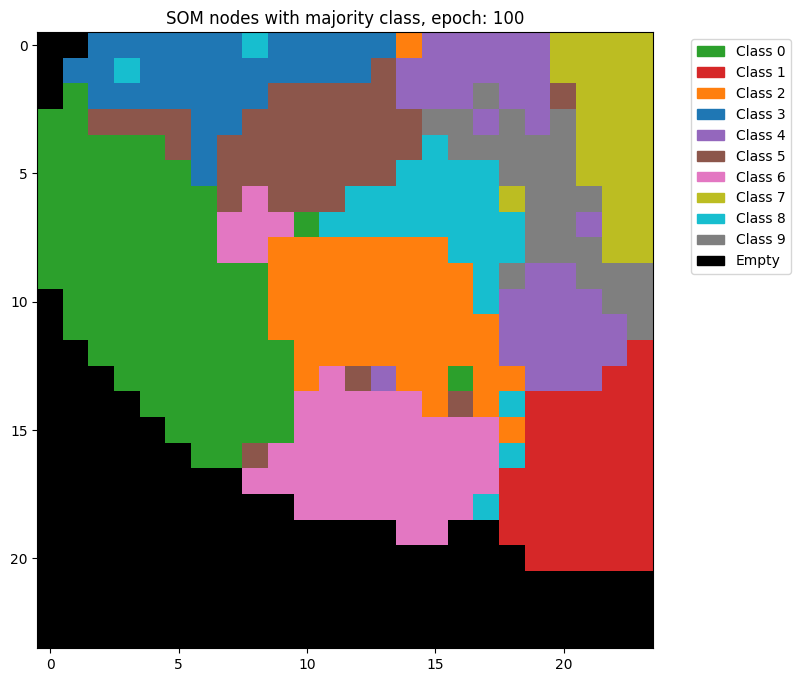

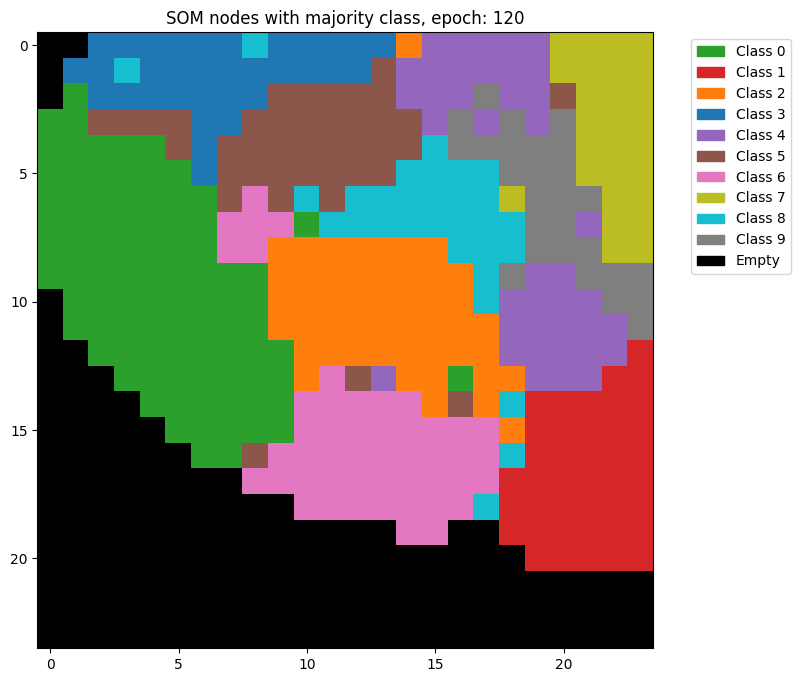

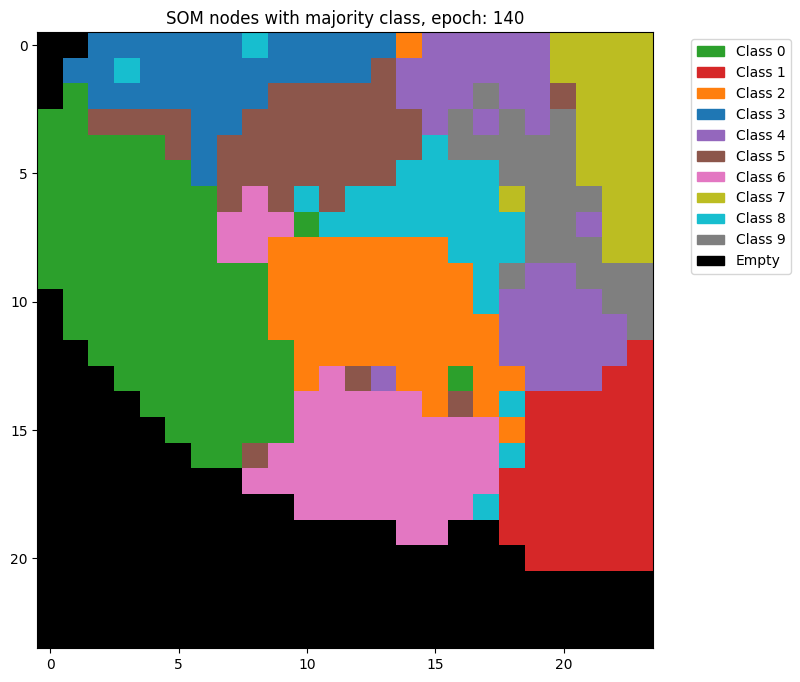

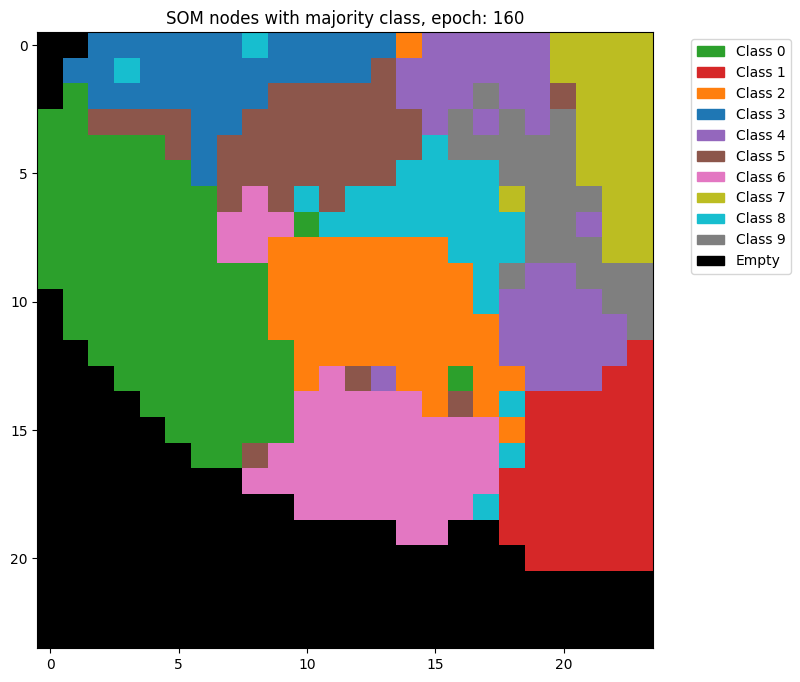

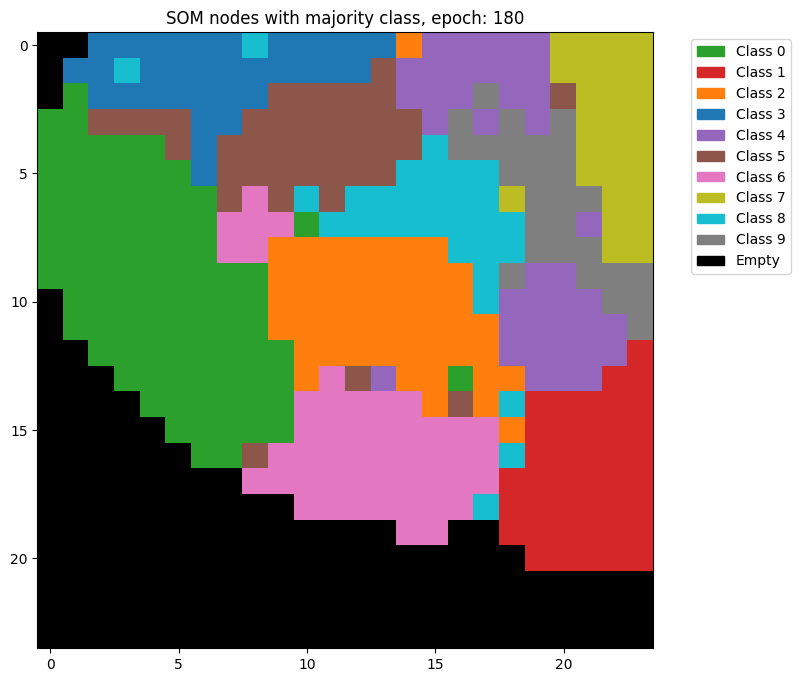

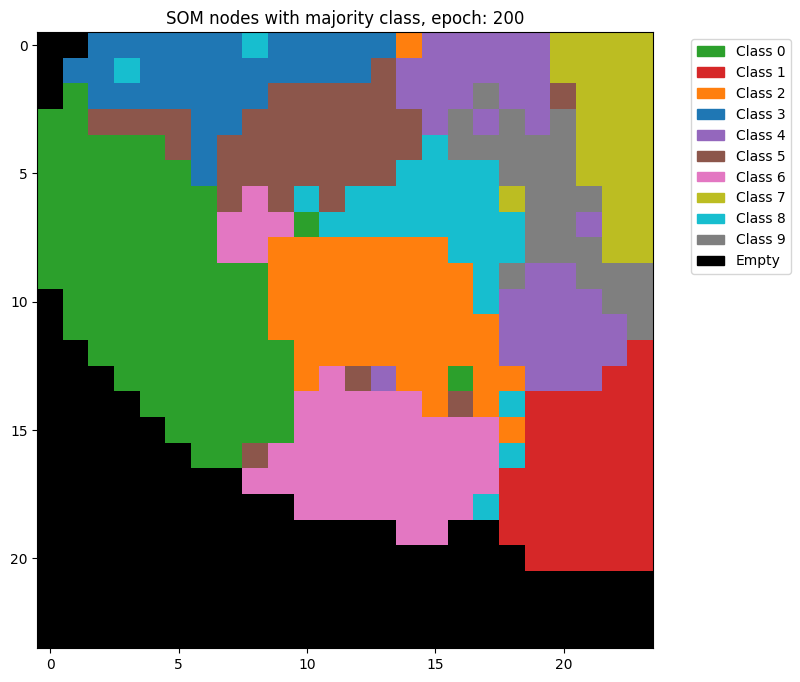

In [22]:
plot_som_weights(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'], unique_labels)

Plot the change of the UMAP throughout the training process

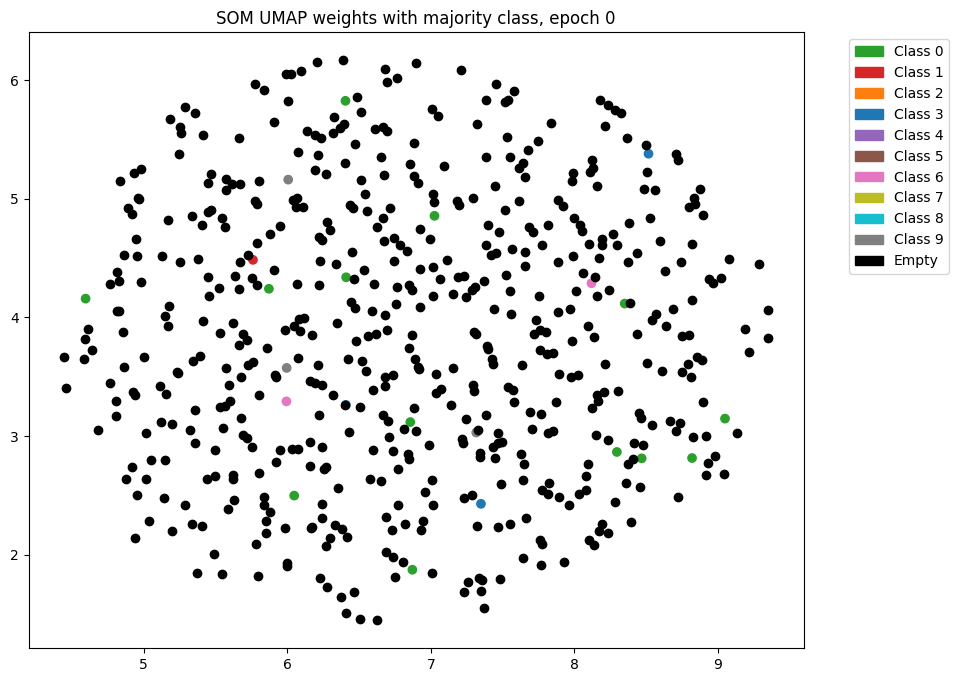

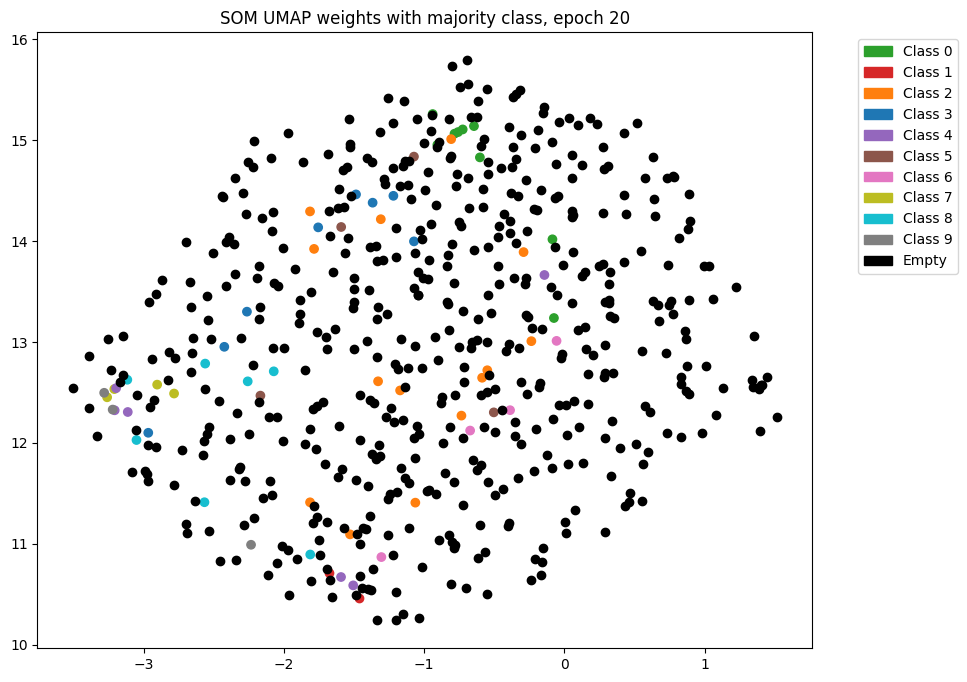

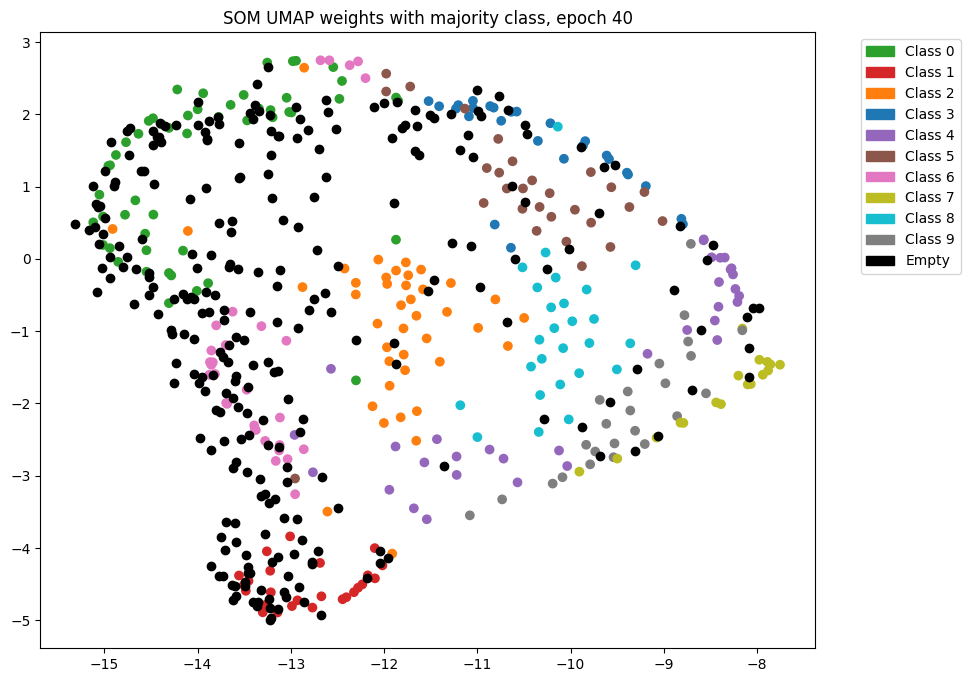

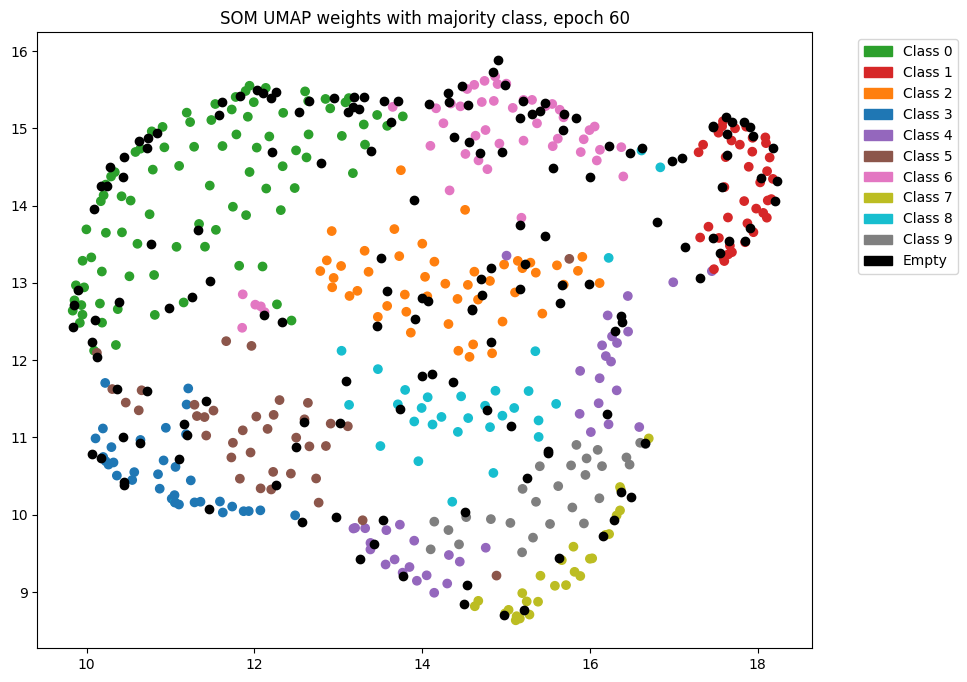

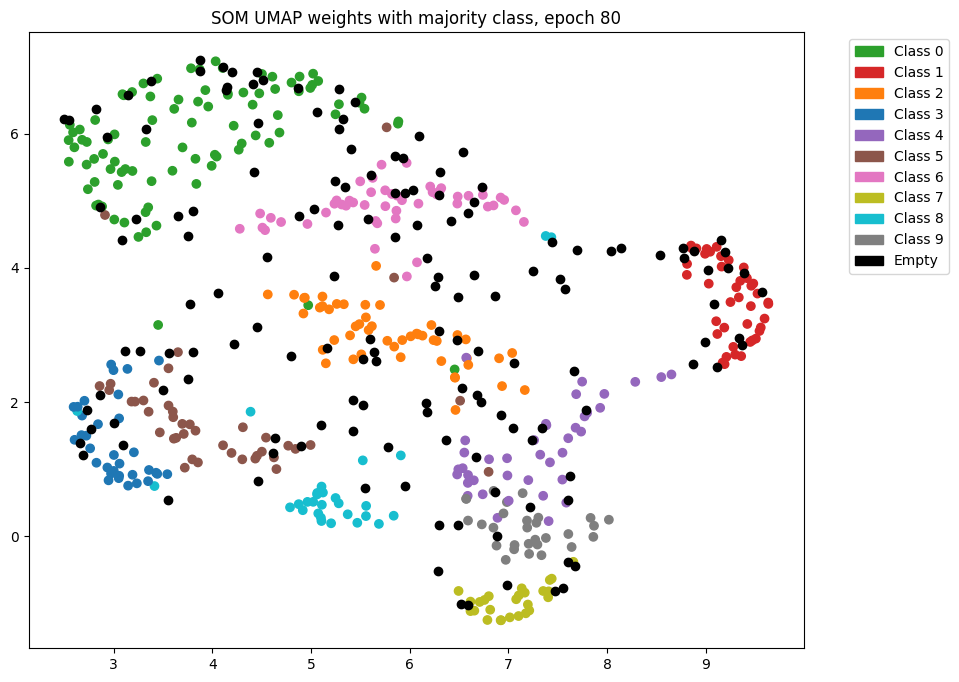

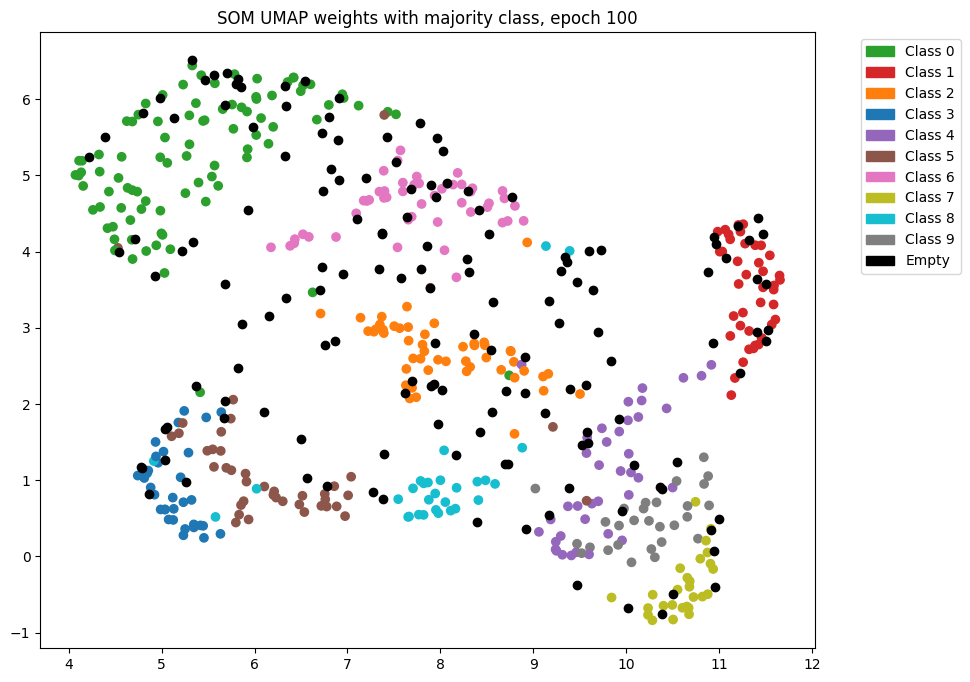

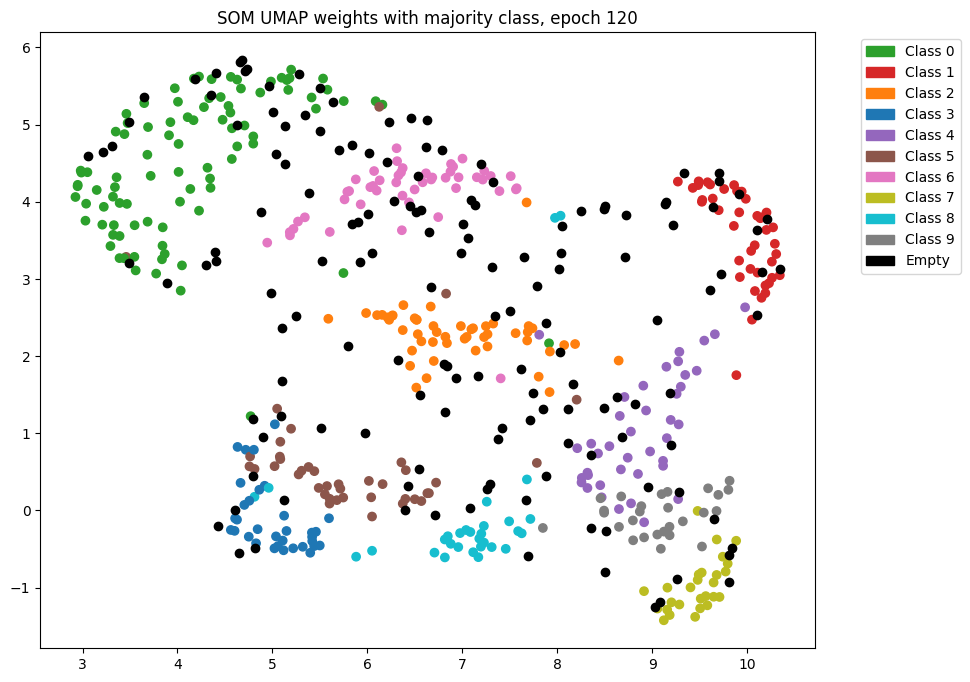

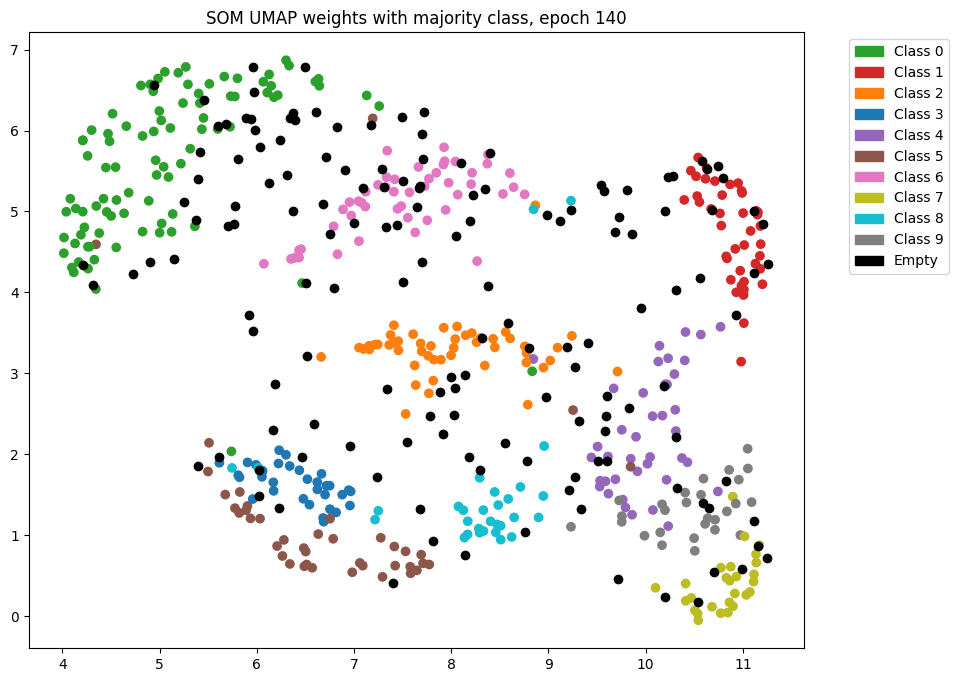

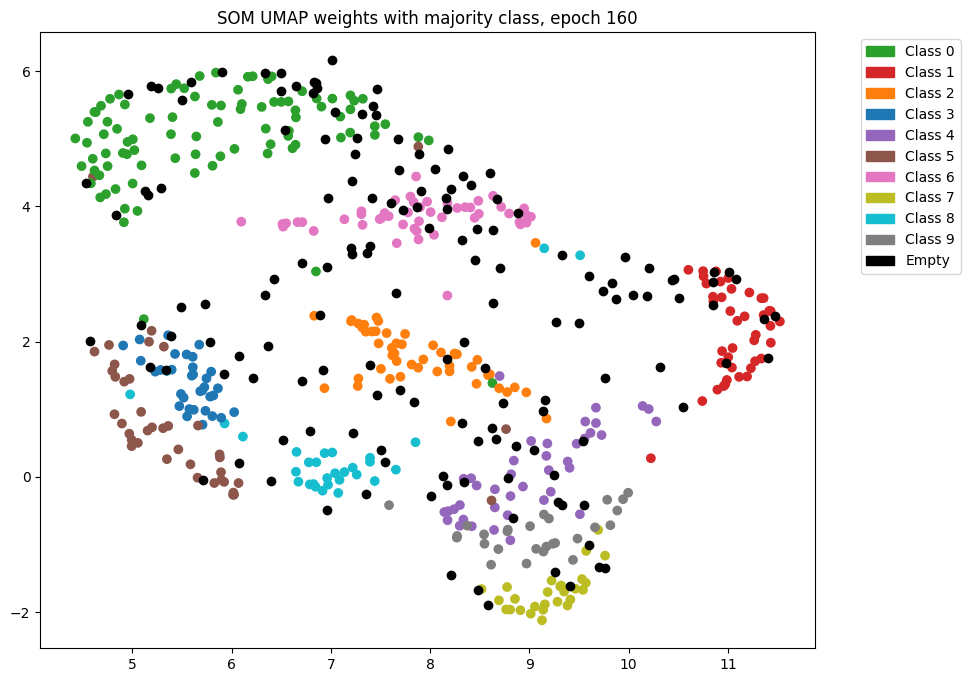

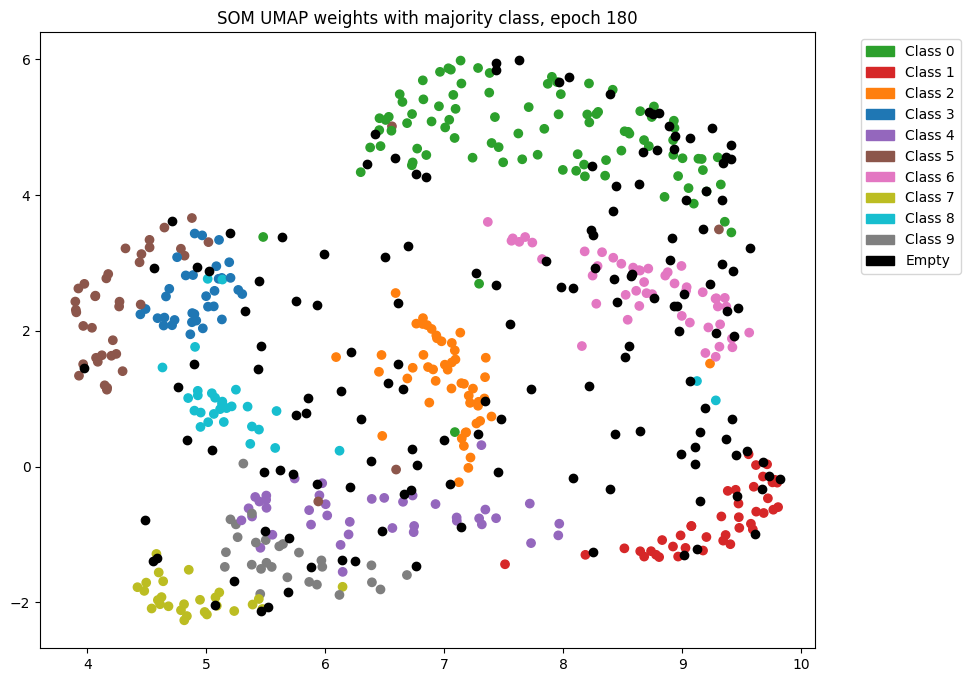

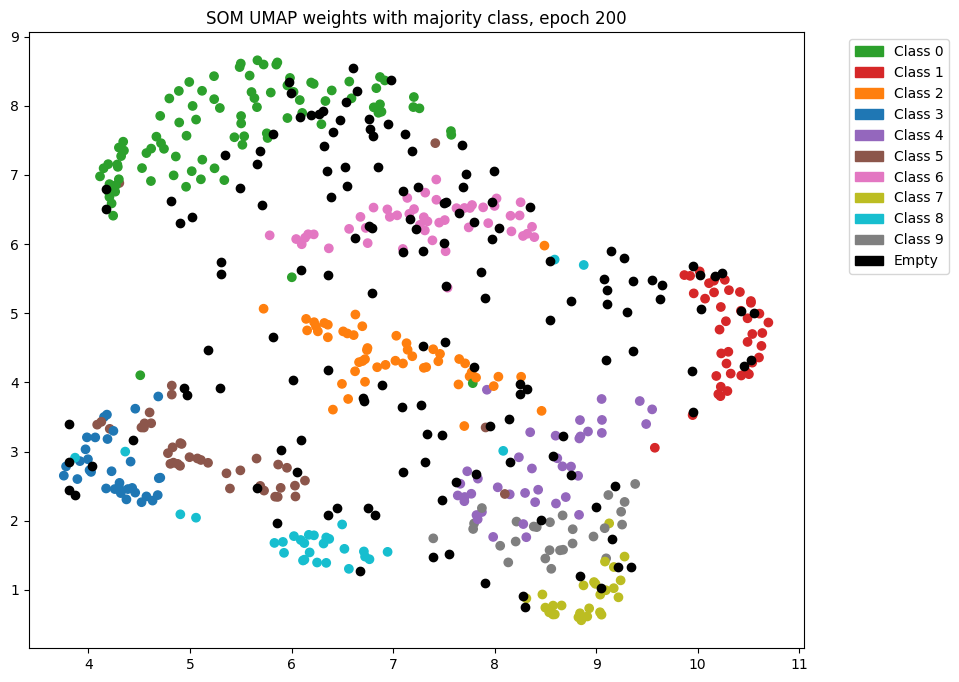

In [23]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

Plot the majority class with the numbers representing the class

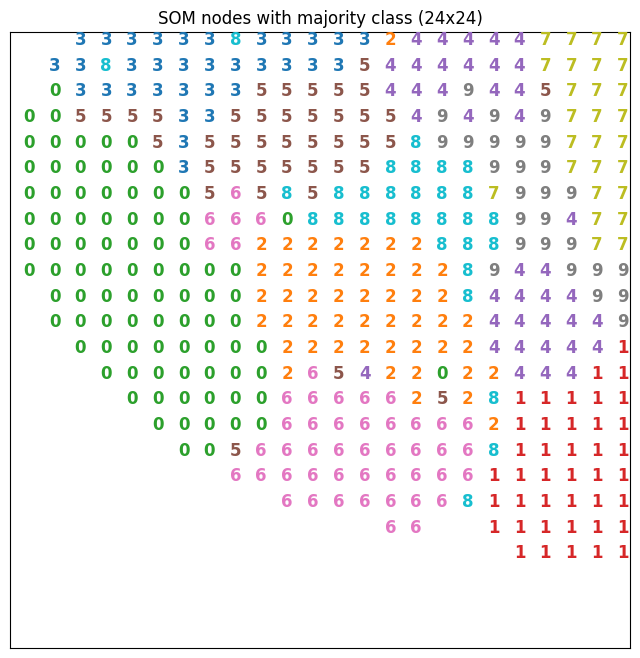

In [24]:
plot_som_mnist(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'])

Plot the pie charts with internal class distributions

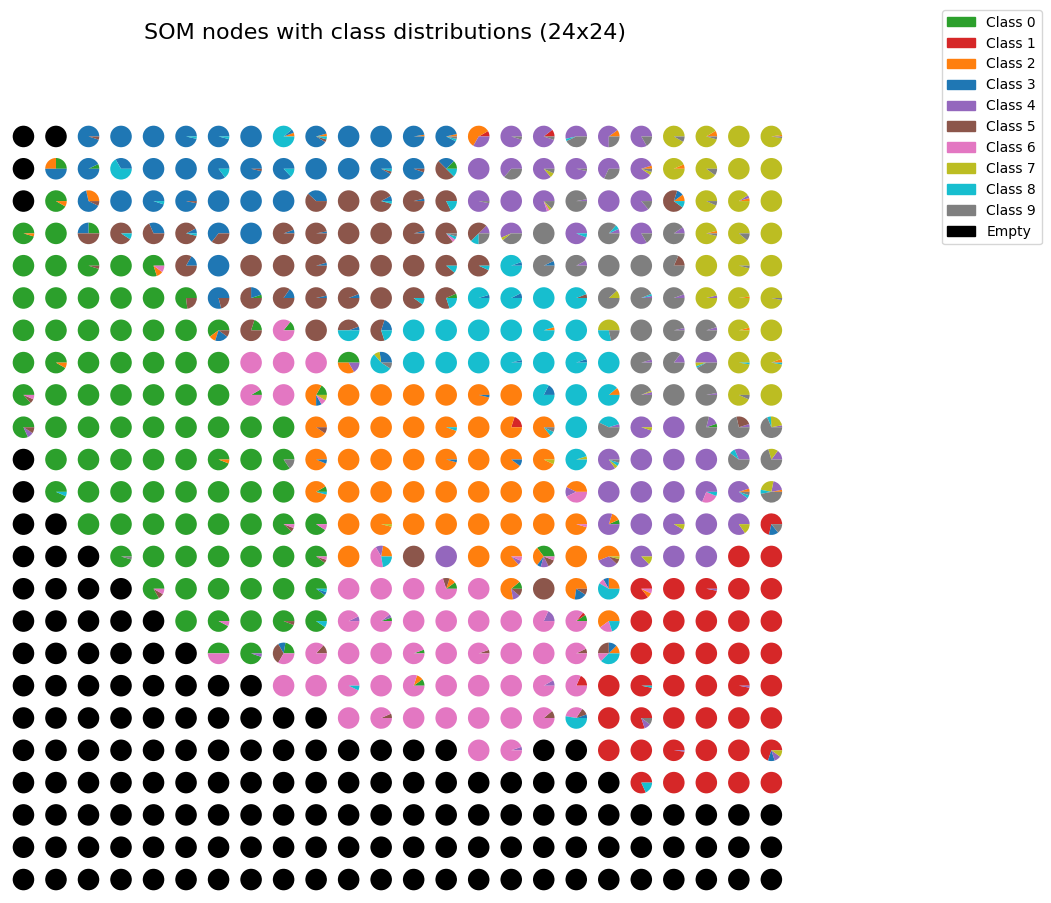

In [25]:
plot_som_pie_grid(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'], unique_labels)

## ViT-SOM with 40x40 grid

In [37]:
config_paper_big = {
    'img_size': 16,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'som_rows': 40,
    'som_cols': 40,
    'epochs': 200,
    'lr': 0.0005,
}

Initialize the ViT-SOM

Details:
- Image size of 16
- Pixel size of 4
- 1 image channel
- Embedding dimension of 16
- Encoder depth of 4
- Decoder depth of 2
- 2 self-attention head
- MLP hidden dimension of size 64
- 40 SOM rows
- 40 SOM columns
- 200 training epochs


In [38]:
autoencoder_big = AutoEncoder(img_size=config_paper_big['img_size'], 
                          patch_size=config_paper_big['patch_size'], 
                          num_of_channels=config_paper_big['num_of_channels'], 
                          embed_dim=config_paper_big['embed_dim'], 
                          enc_depth=config_paper_big['enc_depth'],                                      
                          dec_depth=config_paper_big['dec_depth'], 
                          num_heads=config_paper_big['num_heads'], 
                          mlp_dim=config_paper_big['mlp_dim'], 
                          som_rows=config_paper_big['som_rows'], 
                          som_cols=config_paper_big['som_cols'])    

In [39]:
optimizer = optim.AdamW(autoencoder_big.parameters(), lr=config_paper_big['lr'])
loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
criterionViT = ViTLoss()
criterionSOM = SomLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=config_paper_big['epochs'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder_big.to(device)
autoencoder_big.train()

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = 5
sigma_end = 0.001
beta = (sigma_end / sigma_start) ** (1 / config_paper_big['epochs'])

grid_coords = get_grid_coords(config_paper_big['som_rows'], config_paper_big['som_cols'], device)
current_sigma = sigma_start

history = {'total': [], 'mse': [], 'som': [], 'purity': [], 'QE': [], 'TE': []}

checkpoints = [0,20,40,60,80,100,120,140,160,180,200]
snapshot_som_weights = {}

snapshot_som_weights[0] = (
    autoencoder_big.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder_big, loader, device)
)

unique_labels = set()

warmup_epochs = 10
target_gamma = 0.01
print("Start training")
for epoch in range(config_paper_big['epochs']):
    running_loss = 0.0
    running_mse = 0.0
    running_som = 0.0
    
    # using linear warmup on the sigma value, this demonstrated better results than standard decaying
    if epoch >= warmup_epochs:
        sigma_t = decay_exponential(sigma_start, beta, epoch - warmup_epochs)
    else:
        sigma_t = sigma_start
    
    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder_big(images)
        som_weights = autoencoder_big.get_som_weights()
        
        # calculate the total loss using the linear warmup
        l_nn = criterionViT(images, reconstructed)
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        if epoch < warmup_epochs:
            gamma = target_gamma * (epoch / warmup_epochs)
        else:
            gamma = target_gamma
        total_loss = l_nn + gamma * l_som
        
        # update the weights of the network
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_mse += l_nn.item()
        running_som += l_som.item()
    
    if epoch+1 in checkpoints:      
        weights_np = autoencoder_big.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder_big, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)
        
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()
    metrics = calculate_QE_TE_Purity(autoencoder_big, loader, device)
    
    avg_total = running_loss / len(loader)
    avg_mse = running_mse / len(loader)
    avg_som = running_som / len(loader)
    
    history['total'].append(avg_total)
    history['mse'].append(avg_mse)
    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config_paper_big['epochs']} | Sigma: {sigma_t:.2f} | Loss: {avg_total:.8f} (MSE: {avg_mse:.8f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")


Start training
Epoch 1/200 | Sigma: 5.00 | Loss: 0.04608074 (MSE: 0.04608074 | SOM: 125.54707056) | QE: 0.8071 | TE: 0.9986 | Purity: 0.50043
Epoch 2/200 | Sigma: 5.00 | Loss: 0.12085189 (MSE: 0.00600446 | SOM: 114.84742228) | QE: 0.5360 | TE: 0.2741 | Purity: 0.22983
Epoch 3/200 | Sigma: 5.00 | Loss: 0.16663281 (MSE: 0.00336813 | SOM: 81.63233893) | QE: 0.3195 | TE: 1.0000 | Purity: 0.18692
Epoch 4/200 | Sigma: 5.00 | Loss: 0.17968836 (MSE: 0.00238420 | SOM: 59.10138692) | QE: 0.2094 | TE: 1.0000 | Purity: 0.16703
Epoch 5/200 | Sigma: 5.00 | Loss: 0.17519955 (MSE: 0.00199295 | SOM: 43.30164973) | QE: 0.1380 | TE: 1.0000 | Purity: 0.16703
Epoch 6/200 | Sigma: 5.00 | Loss: 0.15929012 (MSE: 0.00177509 | SOM: 31.50300613) | QE: 0.0898 | TE: 1.0000 | Purity: 0.16703
Epoch 7/200 | Sigma: 5.00 | Loss: 0.13695440 (MSE: 0.00163077 | SOM: 22.55393876) | QE: 0.0567 | TE: 1.0000 | Purity: 0.16703
Epoch 8/200 | Sigma: 5.00 | Loss: 0.11241151 (MSE: 0.00152281 | SOM: 15.84124154) | QE: 0.0342 | TE: 

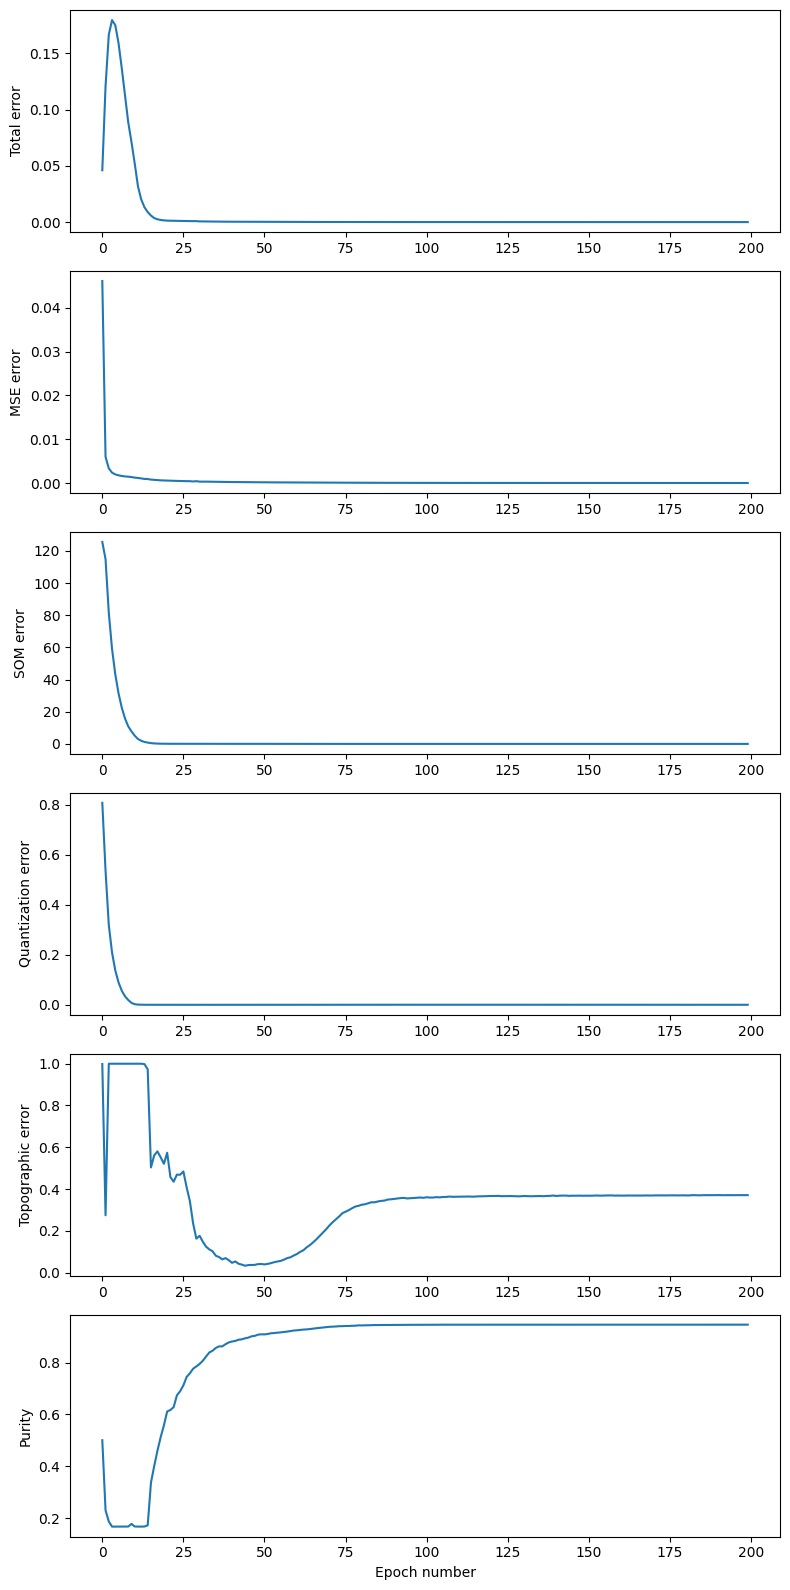

In [40]:
plt.figure(figsize=(8, 16))
plt.subplot(6,1,1)
plt.plot(np.arange(config_paper_big['epochs']), history['total'])
plt.ylabel('Total error')
plt.subplot(6,1,2)
plt.plot(np.arange(config_paper_big['epochs']), history['mse'])
plt.ylabel('MSE error')
plt.subplot(6,1,3)
plt.plot(np.arange(config_paper_big['epochs']), history['som'])
plt.ylabel('SOM error')
plt.subplot(6,1,4)
plt.plot(np.arange(config_paper_big['epochs']), history['QE'])
plt.ylabel('Quantization error')
plt.subplot(6,1,5)
plt.plot(np.arange(config_paper_big['epochs']), history['TE'])
plt.ylabel('Topographic error')
plt.subplot(6,1,6)
plt.plot(np.arange(config_paper_big['epochs']), history['purity'])
plt.ylabel('Purity')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

Plot the change of the label matrix throughout the training process

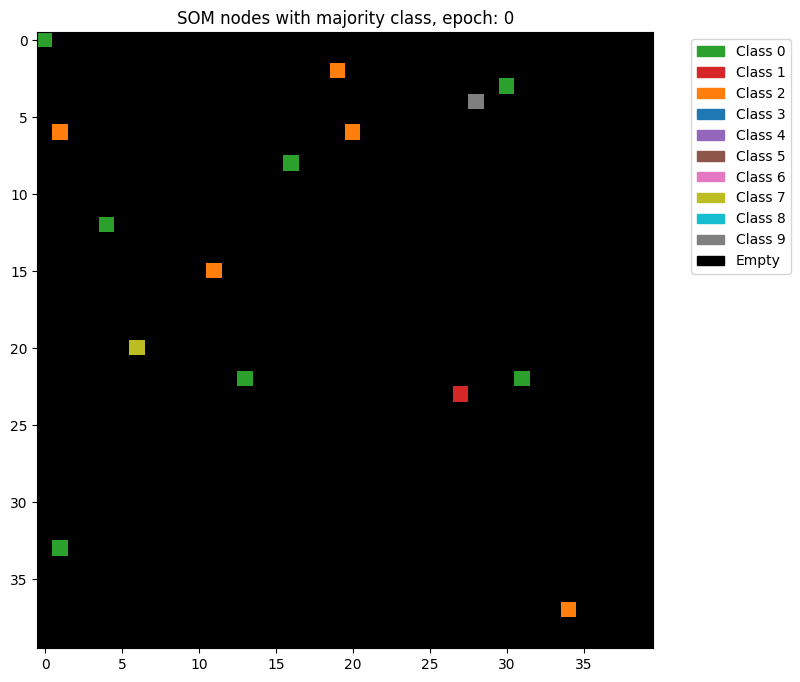

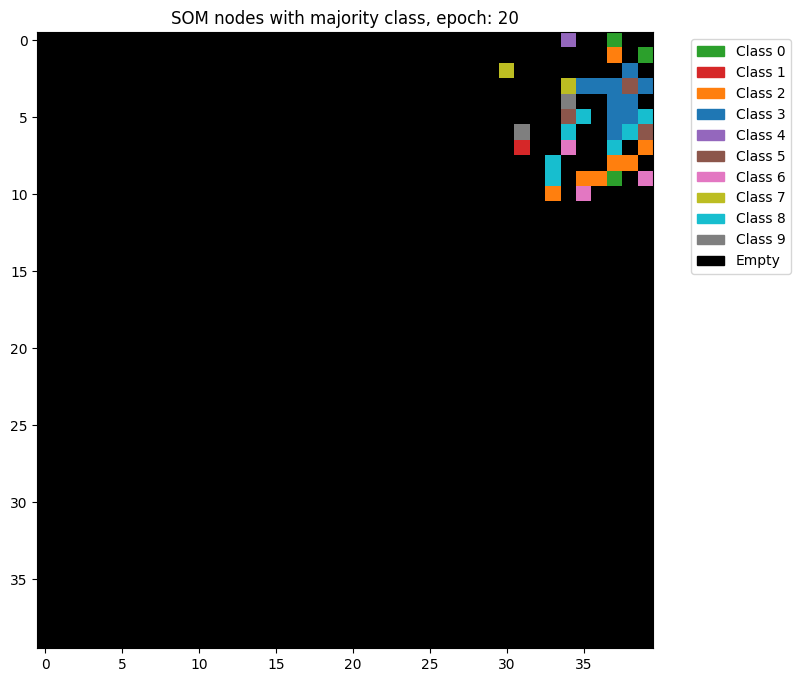

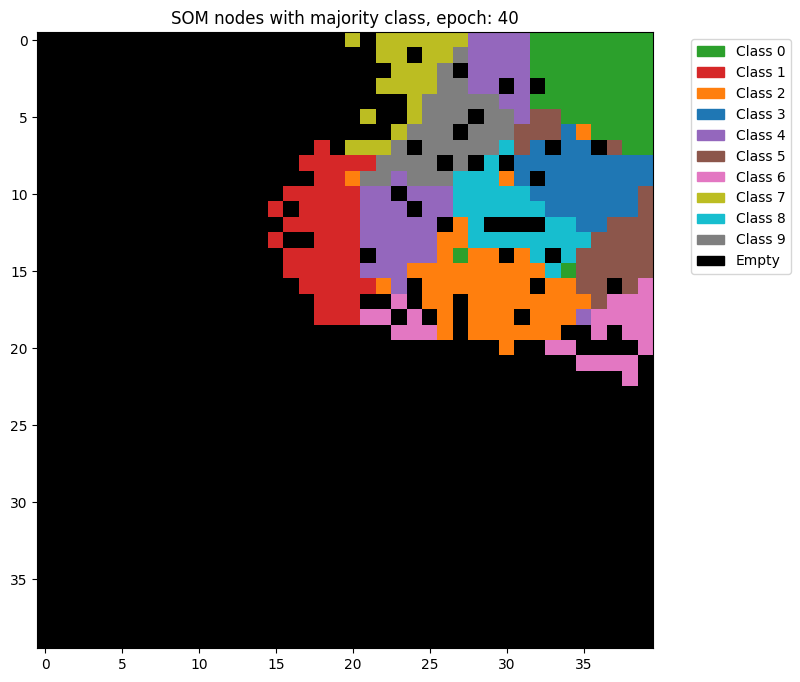

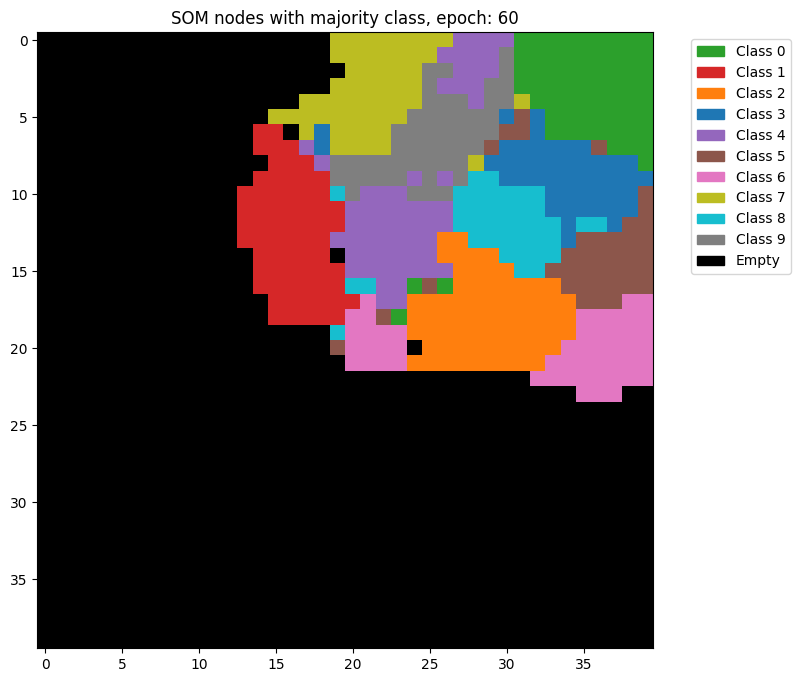

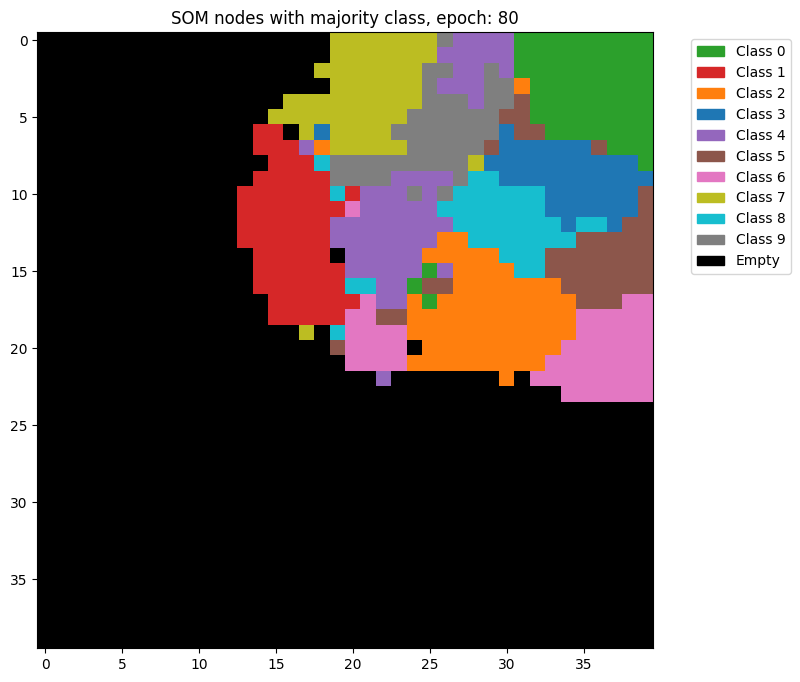

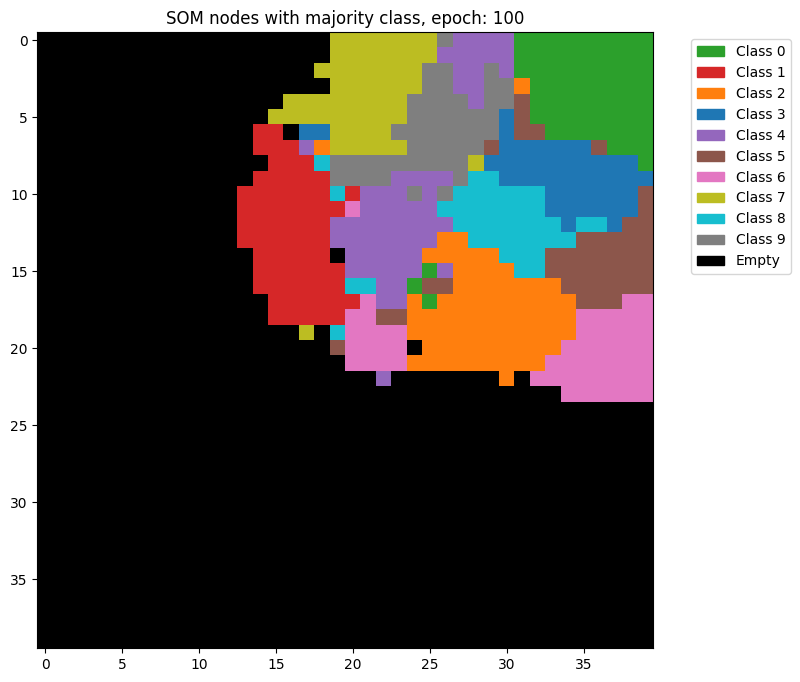

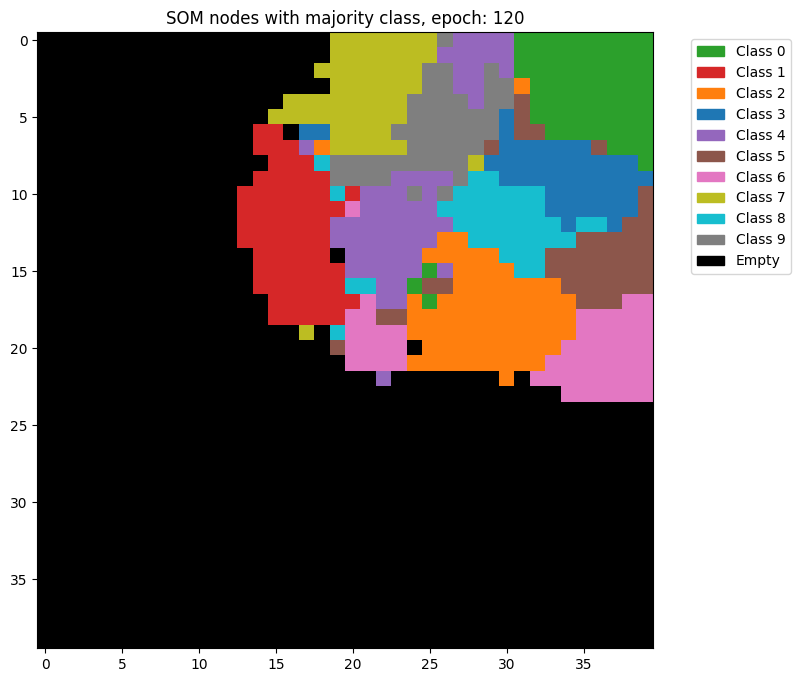

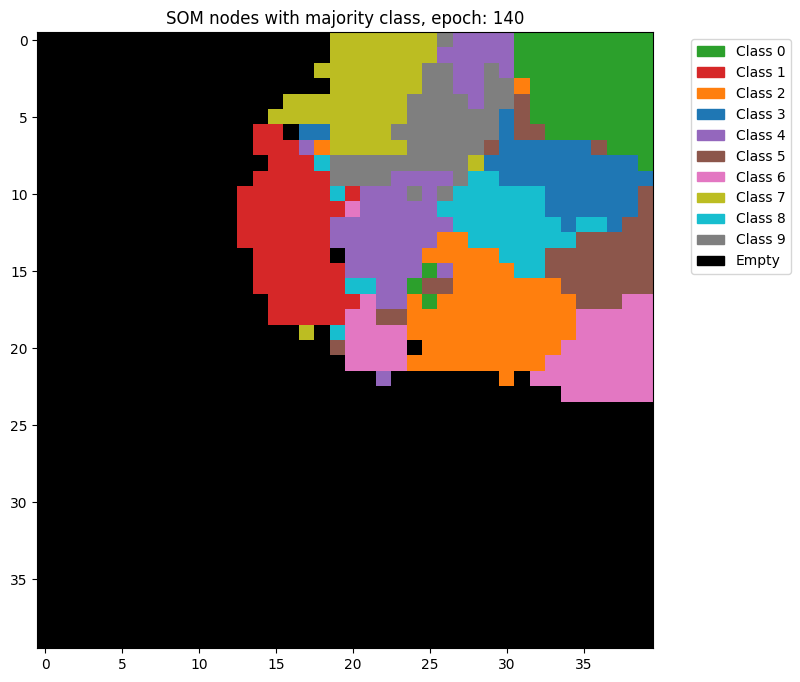

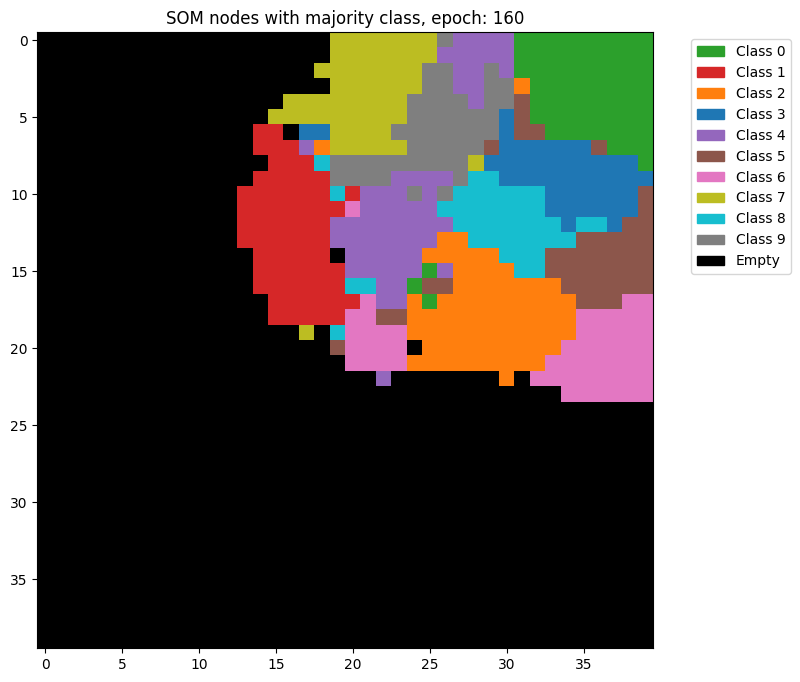

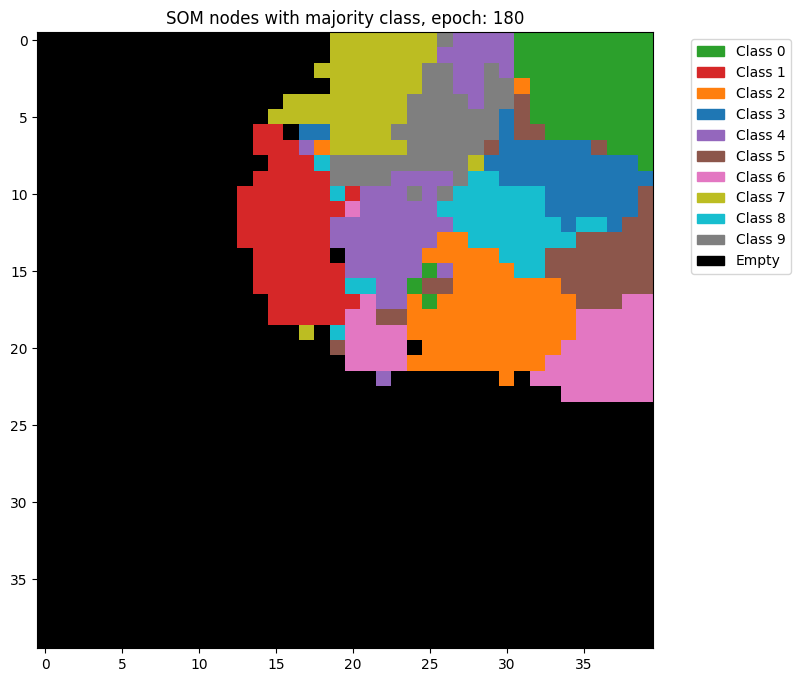

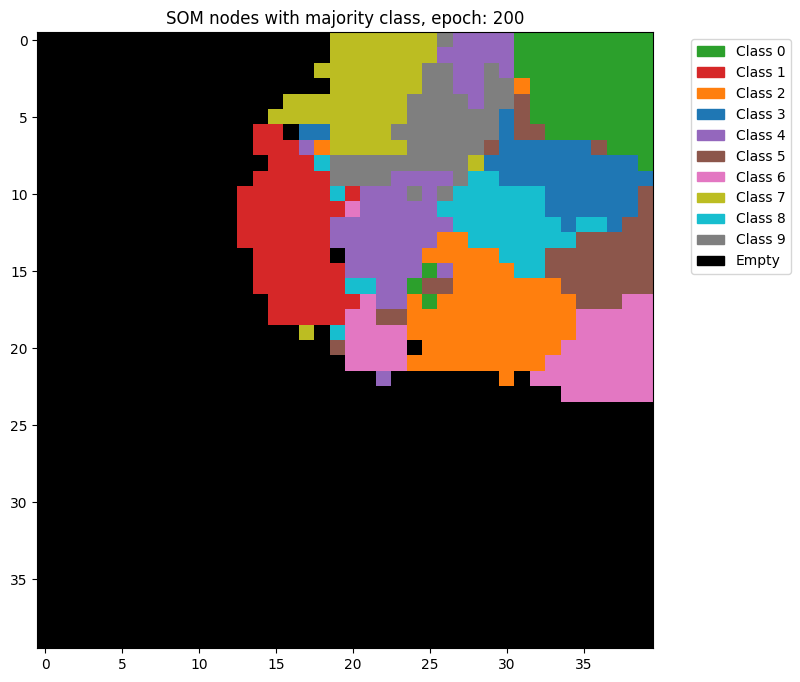

In [41]:
plot_som_weights(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'], unique_labels)

Plot the change of the UMAP throughout the training process

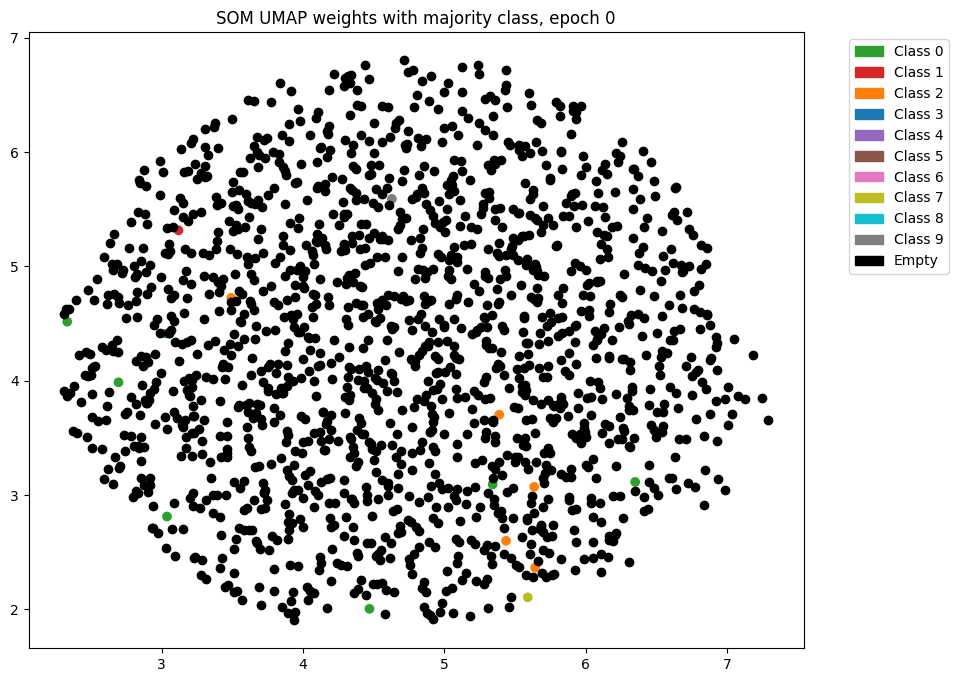

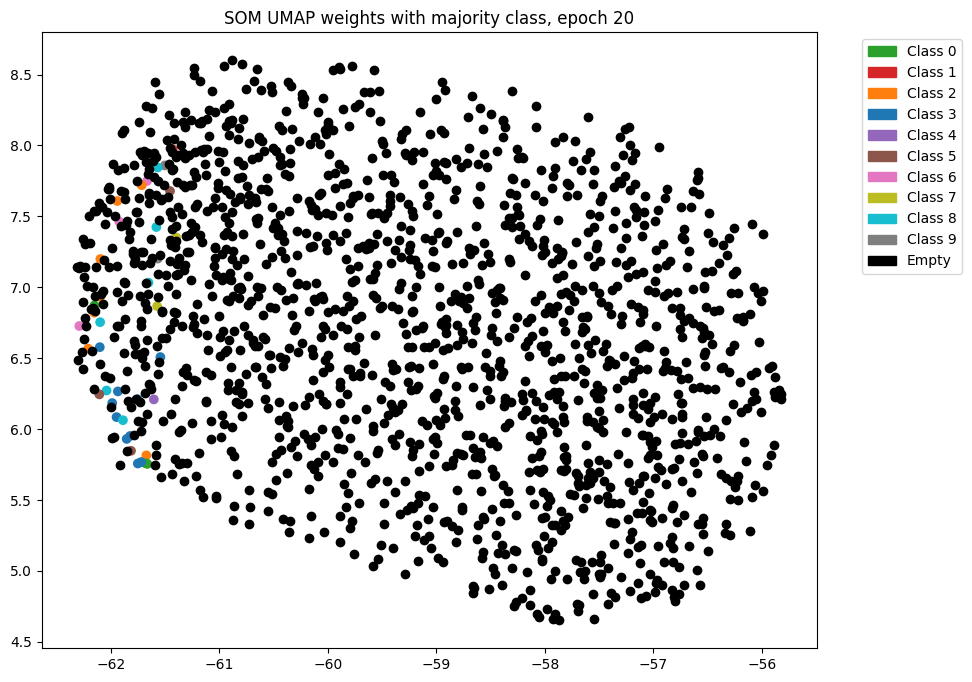

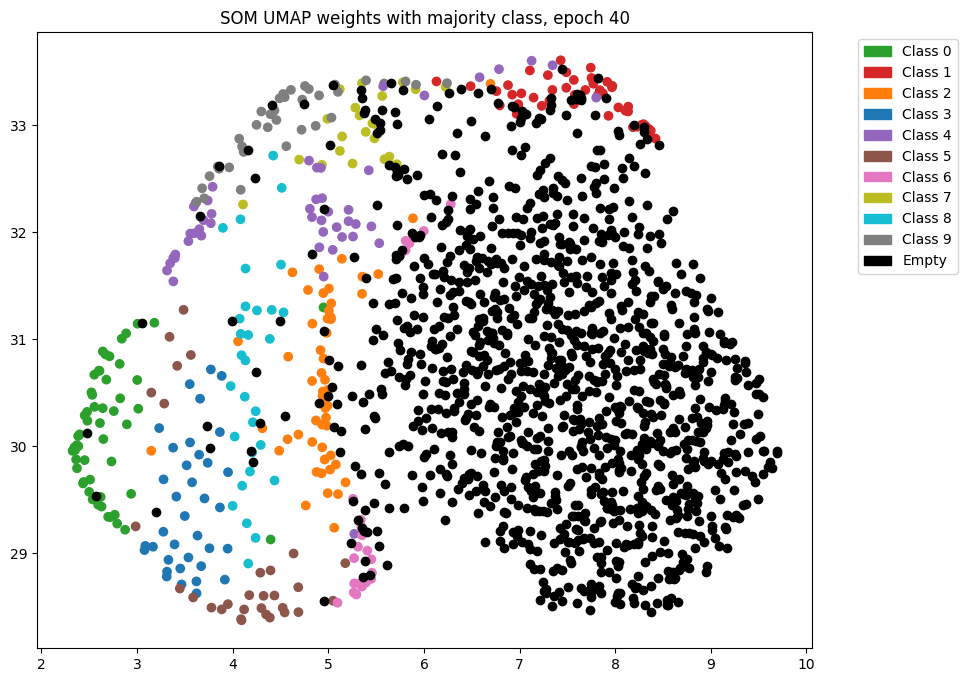

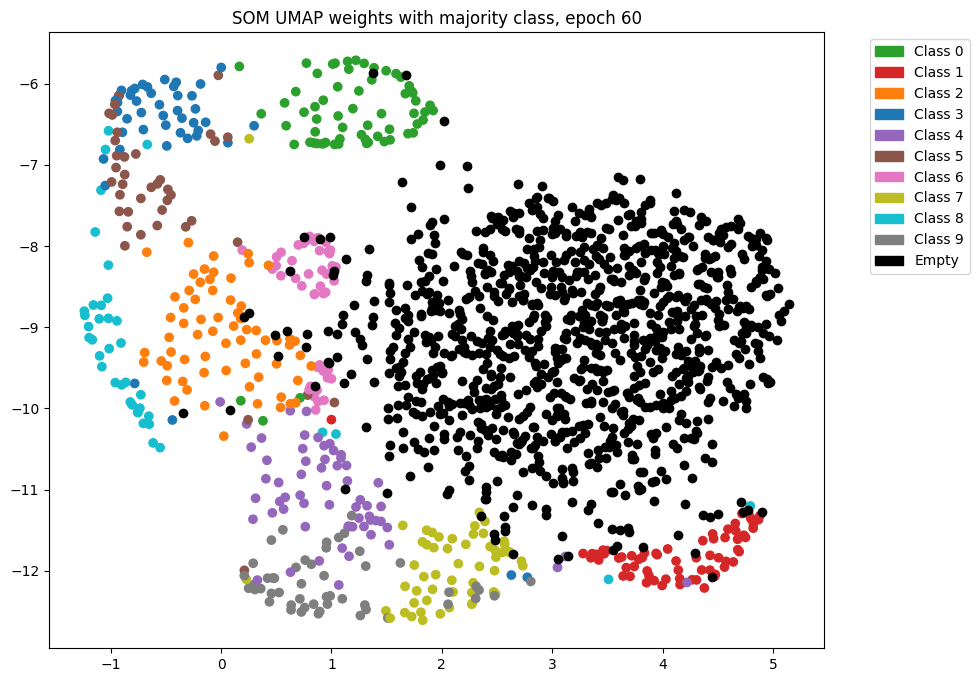

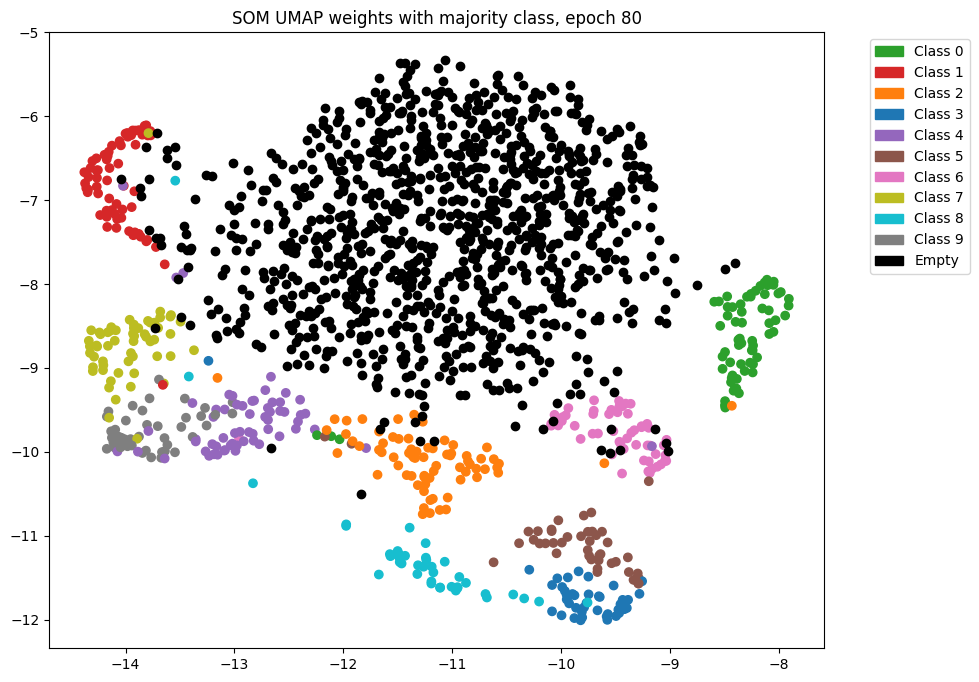

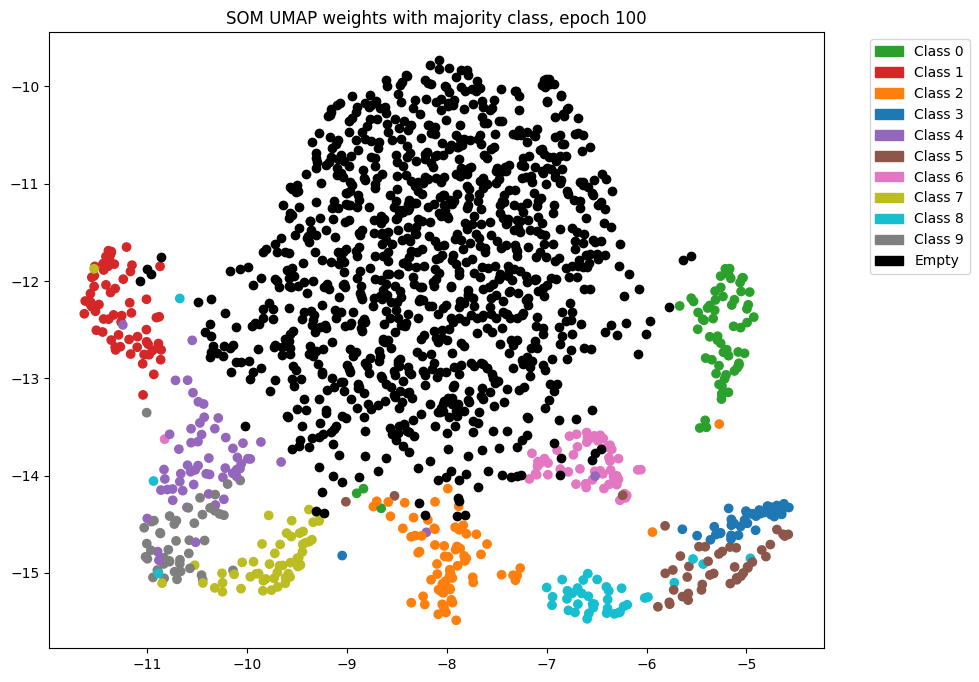

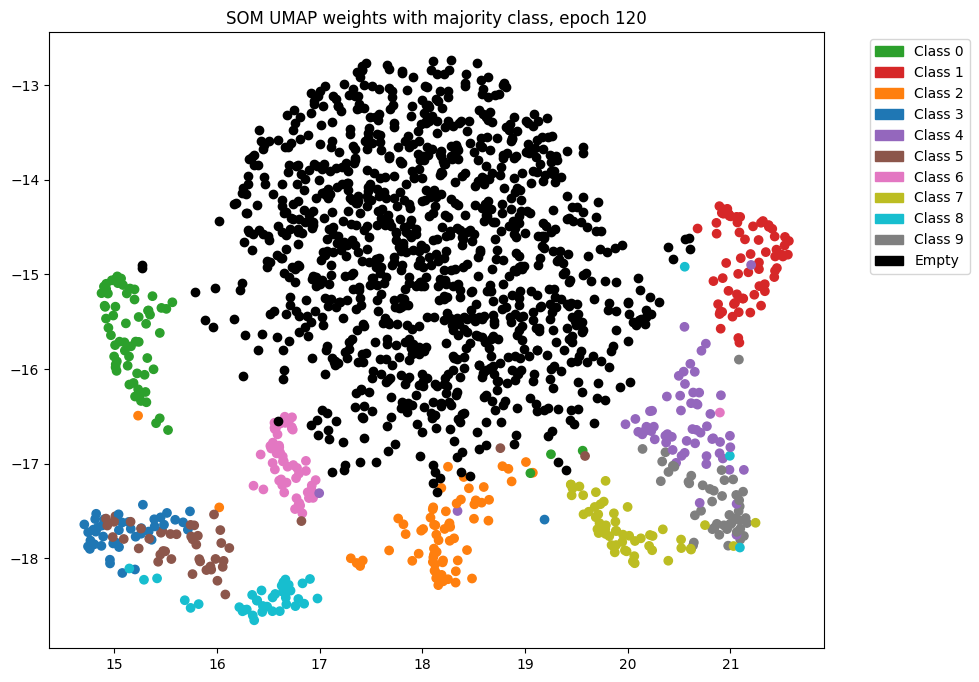

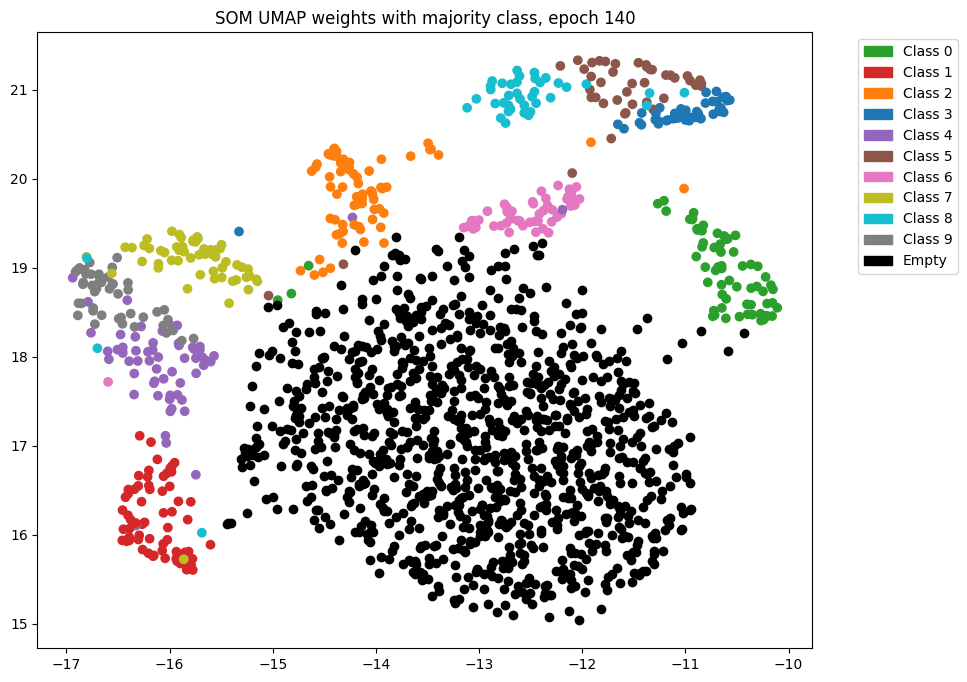

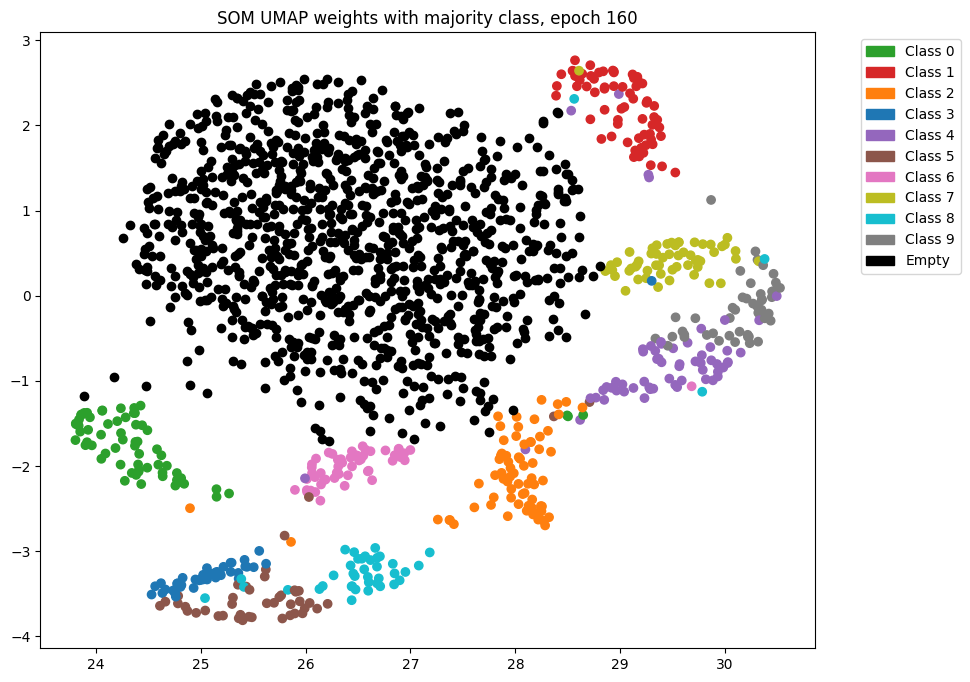

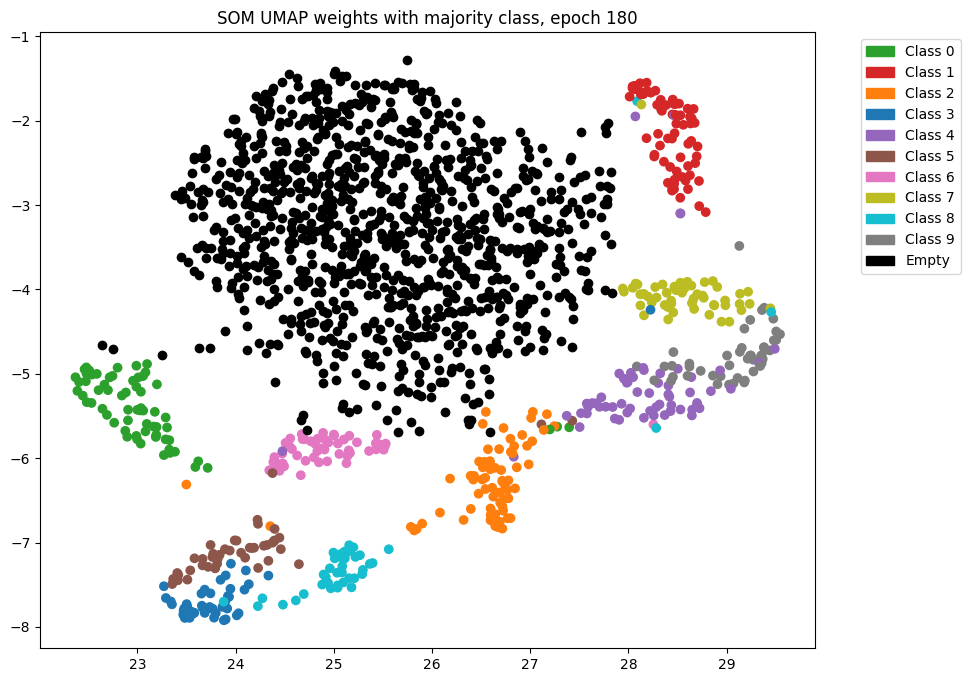

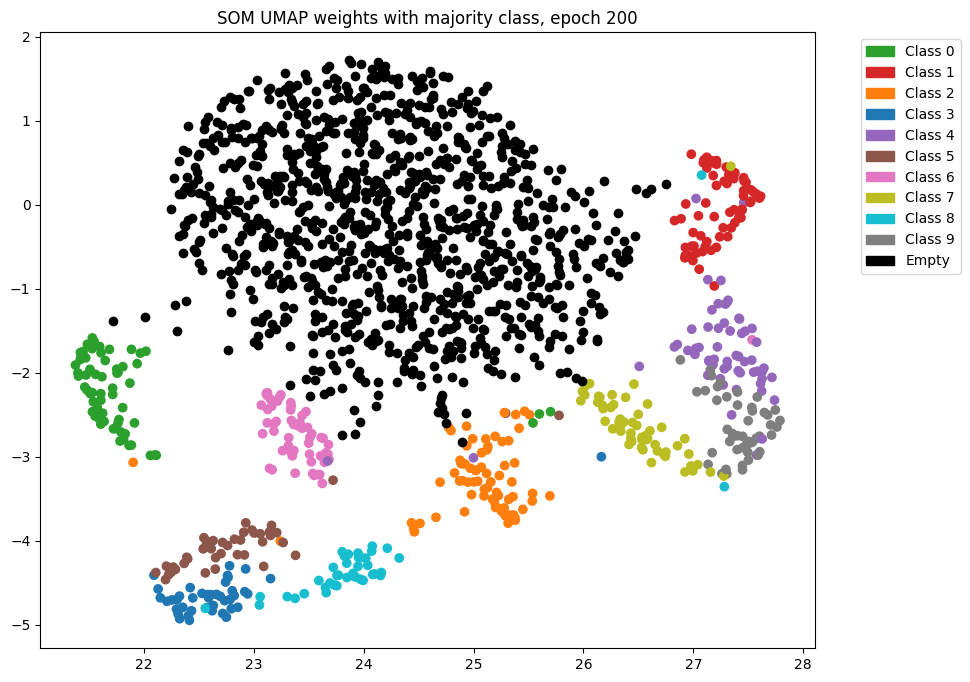

In [42]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

Plot the majority class with the numbers representing the class

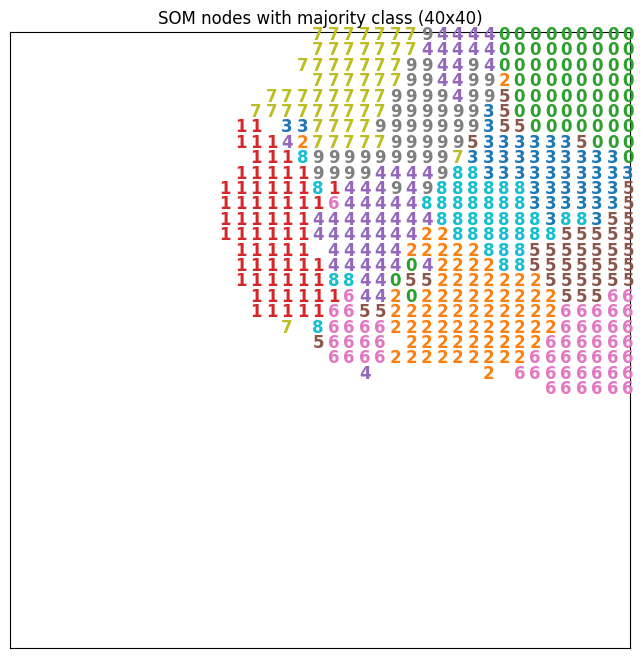

In [43]:
plot_som_mnist(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'])

Plot the pie charts with internal class distributions

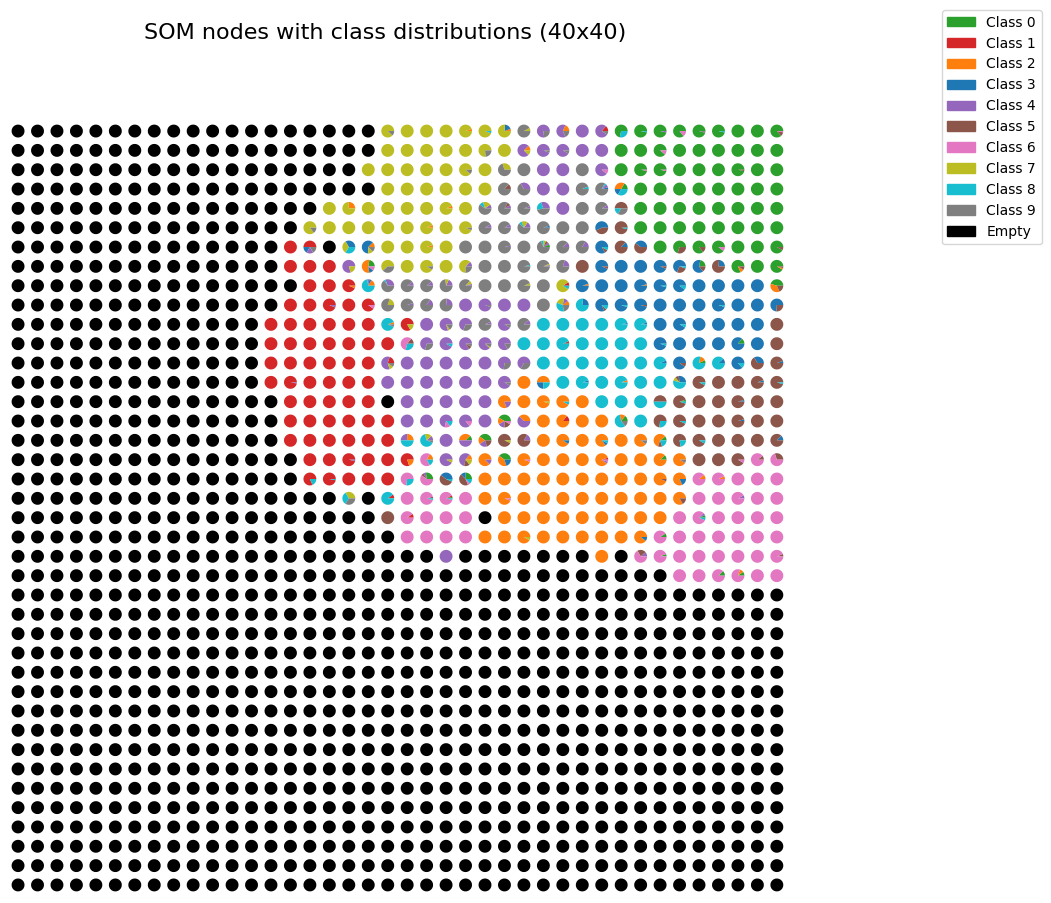

In [44]:
plot_som_pie_grid(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'], unique_labels)